# Sepsis Shock Prediction using Machine Learning: A Technical Report

## Abstract

This report details the development and evaluation of machine learning models for early prediction of sepsis shock using physiological data. Given the absence of a direct 'sepsis shock' label, a proxy target variable was engineered based on established clinical criteria (hypotension, tachycardia, tachypnea, and temperature abnormalities). The dataset exhibited extreme class imbalance, which was addressed through various sampling and weighting techniques. Three classification models—Logistic Regression, Random Forest, and LightGBM—were trained and rigorously evaluated using metrics suitable for imbalanced datasets, including Accuracy, Precision, Recall, F1-Score, and ROC AUC. Furthermore, a critical analysis of model performance across demographic subgroups (sex and age) was conducted to assess potential biases and fairness implications. The findings highlight the effectiveness of ensemble methods in identifying rare events and underscore the importance of careful consideration of data limitations and ethical implications in healthcare AI.

## 1. Introduction

Sepsis is a life-threatening organ dysfunction caused by a dysregulated host response to infection. Sepsis shock, a severe form of sepsis, is characterized by persistent hypotension requiring vasopressors to maintain mean arterial pressure (MAP) $\geq 65$ mmHg and a serum lactate level $> 2$ mmol/L despite adequate fluid resuscitation. Early detection and intervention are crucial for improving patient outcomes and reducing mortality.

This project aims to develop machine learning models to predict the onset of sepsis shock using routinely collected physiological data. Due to the lack of direct clinical diagnostic markers like vasopressor use or lactate levels in the provided dataset, a proxy definition of sepsis shock has been formulated based on vital sign abnormalities. The primary objective is to evaluate the performance of different classification algorithms in predicting this proxy, while also addressing challenges such as class imbalance and potential biases.

## 2. Data Loading and Preprocessing

The initial phase involved loading the healthcare dataset and preparing it for analysis and modeling. This included handling missing values, inspecting data types, and ensuring data quality.

### Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import pandas as pd

# Example: loading a CSV file from Google Drive
# Make sure to replace 'path/to/your_file.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/MyDrive/my_data.csv'
file_path = '/content/drive/MyDrive/healthcare_data.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your Google Drive.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Successfully loaded data from /content/drive/MyDrive/healthcare_data.csv:


,patient_id,time_sec,age,sex,bmi,heart_rate,systolic_bp,diastolic_bp,spo2,resp_rate,temp_c,activity_level,stress_index,blood_glucose_mmol_l,pain_score,medication_flag
0,P001,0,85,M,27.4,92.4,138.3,75.5,97.3,19.0,36.86,0,3.37,5.27,1.92,0
1,P001,1,85,M,27.4,92.9,139.6,76.5,96.1,18.7,36.85,2,3.61,5.51,1.83,0
2,P001,2,85,M,27.4,NaN,138.4,74.9,96.9,19.2,36.85,0,3.59,5.53,1.85,0
3,P001,3,85,M,27.4,93.6,138.2,76.7,97.3,19.3,36.85,3,3.70,5.55,1.70,0
4,P001,4,85,M,27.4,92.8,137.0,75.2,96.4,18.6,36.86,3,3.51,5.49,1.73,0


### Check Missing Entries

In [5]:
print('Missing values per column:')
display(df.isnull().sum())

Missing values per column:


,0
patient_id,0
time_sec,0
age,0
sex,0
bmi,0
heart_rate,7200
systolic_bp,7200
diastolic_bp,7200
spo2,7200
resp_rate,7200


### Impute Missing Values

I will impute the missing values using linear interpolation. This method estimates the missing values based on the values immediately before and after them. Since this is time-series data, I will perform this imputation grouped by `patient_id` to maintain the integrity of each patient's data.

In [6]:
# Columns with missing values identified in the previous step
columns_to_impute = [
    'heart_rate', 'systolic_bp', 'diastolic_bp', 'spo2',
    'resp_rate', 'temp_c', 'stress_index', 'blood_glucose_mmol_l'
]

# Impute missing values using linear interpolation, grouped by patient_id
for col in columns_to_impute:
    df[col] = df.groupby('patient_id')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

print('Missing values after imputation:')
#display(df.isnull().sum())

Missing values after imputation:


### Dataset Structure and Data Quality Overview

In [7]:
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144000 entries, 0 to 143999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   patient_id            144000 non-null  object 
 1   time_sec              144000 non-null  int64  
 2   age                   144000 non-null  int64  
 3   sex                   144000 non-null  object 
 4   bmi                   144000 non-null  float64
 5   heart_rate            144000 non-null  float64
 6   systolic_bp           144000 non-null  float64
 7   diastolic_bp          144000 non-null  float64
 8   spo2                  144000 non-null  float64
 9   resp_rate             144000 non-null  float64
 10  temp_c                144000 non-null  float64
 11  activity_level        144000 non-null  int64  
 12  stress_index          144000 non-null  float64
 13  blood_glucose_mmol_l  144000 non-null  float64
 14  pain_score            144000 non-nul

## 3. Defining the Target Variable: Sepsis Shock

Since the dataset does not include a direct 'sepsis shock' column, we will create a proxy target variable based on common clinical indicators. This approach simplifies the complex clinical diagnosis for machine learning purposes. We will define `sepsis_shock` as a binary variable (1 if conditions for shock are met, 0 otherwise) based on the following criteria, applied per patient at each time point:

*   **Hypotension:** `systolic_bp` < 90 mmHg
*   **Tachycardia:** `heart_rate` > 100 bpm
*   **Tachypnea:** `resp_rate` > 20 bpm
*   **Temperature Abnormality:** (`temp_c` > 38°C or `temp_c` < 36°C)

A time point will be classified as 'sepsis shock' (`sepsis_shock = 1`) if the `systolic_bp` is less than 90 mmHg *and* at least two of the other three criteria (heart rate, respiratory rate, or temperature abnormality) are met. Otherwise, it will be classified as 'no sepsis shock' (`sepsis_shock = 0`).

This is a simplified definition and does not fully encompass the clinical complexity of sepsis shock, which typically involves evidence of organ dysfunction and lactate levels. However, it provides a reasonable starting point for developing predictive models with the available data.

### Reference for Thresholds

The physiological thresholds used here are broadly consistent with criteria from major sepsis definitions, such as the **Sepsis-3 guidelines** (Singer, M., Deutschman, C. S., Seymour, C. W., Shankar-Hari, M., Annane, D., Bauer, M., ... & Hotchkiss, R. S. (2016). The Third International Consensus Definitions for Sepsis and Septic Shock (Sepsis-3). *JAMA*, 315(8), 801-810). While Sepsis-3 primarily focuses on organ dysfunction and specific diagnostic codes, the vital sign derangements used (hypotension, tachycardia, tachypnea, and temperature abnormalities) are fundamental indicators of physiological instability often associated with sepsis and septic shock.

In [8]:
def create_sepsis_shock_label(row):
    hypotension = row['systolic_bp'] < 90
    tachycardia = row['heart_rate'] > 100
    tachypnea = row['resp_rate'] > 20
    temp_abnormal = (row['temp_c'] > 38) or (row['temp_c'] < 36)

    # Count how many of the non-BP criteria are met
    other_criteria_met = sum([tachycardia, tachypnea, temp_abnormal])

    if hypotension and other_criteria_met >= 2:
        return 1
    else:
        return 0

# Apply the function to create the new target column
df['sepsis_shock'] = df.apply(create_sepsis_shock_label, axis=1)

print("Distribution of the new 'sepsis_shock' target variable:")
display(df['sepsis_shock'].value_counts())
display(df['sepsis_shock'].value_counts(normalize=True))

Distribution of the new 'sepsis_shock' target variable:


,count
sepsis_shock,
0,143940
1,60


,proportion
sepsis_shock,
0,0.999583
1,0.000417


/tmp/ipykernel_11942/3553251335.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')


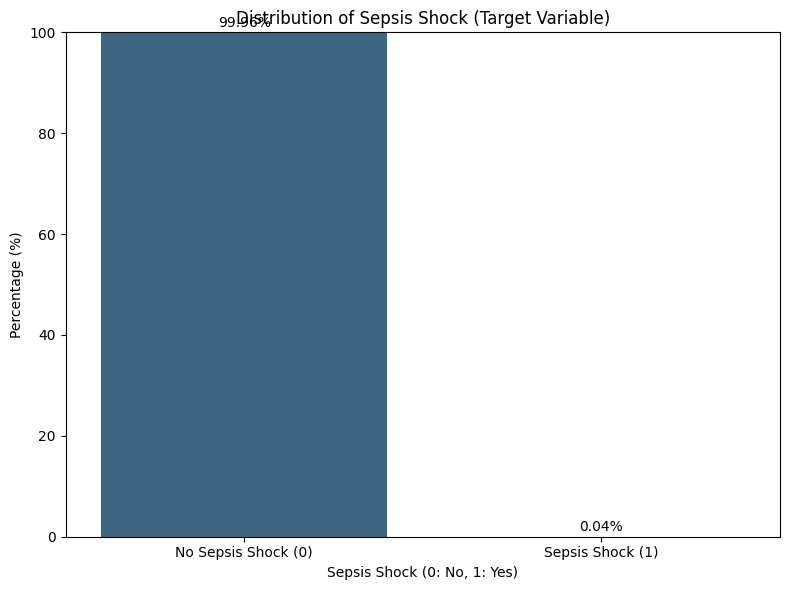

In [9]:
import pandas as pd # Ensure pandas is imported
import matplotlib.pyplot as plt
import seaborn as sns

# --- Start: Ensure df and 'sepsis_shock' column are available ---
# This block is added to handle cases where previous cells defining df or 'sepsis_shock' might not have been run.

# Re-establish file_path if it's not globally available (though it should be from iERwzffcHnb7)
try:
    _ = file_path # Check if file_path is defined
except NameError:
    file_path = '/content/drive/MyDrive/healthcare_data.csv' # If not, define it

if 'df' not in globals(): # Check if df is globally defined
    try:
        df = pd.read_csv(file_path)
        print(f"df was not found in global scope, re-loaded from {file_path}")
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your Google Drive and is mounted.")
        # Propagate the error or handle it gracefully
        raise # Re-raise if file not found, as we can't proceed without data
    except Exception as e:
        print(f"An error occurred while loading the file: {e}")
        raise

if 'sepsis_shock' not in df.columns: # Check if 'sepsis_shock' column exists
    # Re-define the function if it's not in scope. This will always define it just to be safe.
    def create_sepsis_shock_label(row):
        hypotension = row['systolic_bp'] < 90
        tachycardia = row['heart_rate'] > 100
        tachypnea = row['resp_rate'] > 20
        temp_abnormal = (row['temp_c'] > 38) or (row['temp_c'] < 36)

        # Count how many of the non-BP criteria are met
        other_criteria_met = sum([tachycardia, tachypnea, temp_abnormal])

        if hypotension and other_criteria_met >= 2:
            return 1
        else:
            return 0
    df['sepsis_shock'] = df.apply(create_sepsis_shock_label, axis=1)
    print("'sepsis_shock' column was not found, re-created.")
# --- End: Ensure df and 'sepsis_shock' column are available ---


# Calculate the percentage distribution of the target variable
class_distribution = df['sepsis_shock'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')
plt.title('Distribution of Sepsis Shock (Target Variable)')
plt.xlabel('Sepsis Shock (0: No, 1: Yes)')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['No Sepsis Shock (0)', 'Sepsis Shock (1)']) # Custom labels
plt.ylim(0, 100)

# Add percentage labels on top of the bars
for index, value in enumerate(class_distribution.values):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Considerations for the 'sepsis_shock' Target Variable

It's important to acknowledge that the `sepsis_shock` target variable created here is a *proxy* based on the available physiological parameters. The actual clinical diagnosis of sepsis shock is more complex and typically involves:

1.  **Persistent Hypotension:** Requiring vasopressors to maintain MAP >= 65 mmHg.
2.  **Elevated Serum Lactate:** > 2 mmol/L despite adequate fluid resuscitation.

Without information on vasopressor use or serum lactate levels, our current definition serves as an approximation. This could lead to:

*   **False Positives:** Instances where the vital signs meet our criteria, but the patient is not in true sepsis shock (e.g., due to other conditions causing similar vital sign changes).
*   **False Negatives:** Instances where patients are in sepsis shock but their vital signs do not strictly meet our defined thresholds at a given time point, or the shock is managed by interventions not captured in the dataset.

Therefore, the model built on this target variable should be interpreted with these limitations in mind. For a real-world clinical application, a more robust definition incorporating additional clinical context and laboratory markers would be essential.

### Preparing Features and Target for Modeling

Now that we have defined our target variable, `sepsis_shock`, we can prepare our features for model training. The features identified for predicting sepsis shock are:

*   `heart_rate`
*   `systolic_bp`
*   `diastolic_bp`
*   `spo2`
*   `resp_rate`
*   `temp_c`
*   `stress_index`

We will separate these features (`X`) from the target variable (`y`).

In [10]:
features = [
    'heart_rate', 'systolic_bp', 'diastolic_bp', 'spo2',
    'resp_rate', 'temp_c', 'stress_index'
]

X = df[features]
y = df['sepsis_shock']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (144000, 7)
Shape of target (y): (144000,)


### Data Splitting for Model Training and Evaluation

Before training any model, it's crucial to split the dataset into training and testing sets. This allows us to train the model on one subset of the data and evaluate its performance on unseen data, providing a more realistic assessment of its generalization ability. A common split ratio is 80% for training and 20% for testing. Given the extreme class imbalance, we will use stratified sampling to ensure that the proportion of the target variable is maintained in both training and testing sets.

In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of sepsis_shock in training set:")
display(y_train.value_counts(normalize=True))
print("\nDistribution of sepsis_shock in testing set:")
display(y_test.value_counts(normalize=True))

Shape of X_train: (115200, 7)
Shape of X_test: (28800, 7)
Shape of y_train: (115200,)
Shape of y_test: (28800,)

Distribution of sepsis_shock in training set:


,proportion
sepsis_shock,
0,0.999583
1,0.000417



Distribution of sepsis_shock in testing set:


,proportion
sepsis_shock,
0,0.999583
1,0.000417


## 4. Model Training and Evaluation

### Model 1: Logistic Regression

Logistic Regression is a linear model used for binary classification. It estimates the probability of a binary outcome (e.g., sepsis shock or no sepsis shock) based on one or more predictor variables. Despite its name, it's a classification algorithm, not a regression algorithm.

**Justification for choice:**
*   **Interpretability:** Logistic Regression coefficients can be interpreted as the change in the log-odds of the outcome for a one-unit change in the predictor variable.
*   **Baseline Model:** It serves as an excellent baseline for comparison with more complex models due to its simplicity and computational efficiency.
*   **Binary Outcome:** Directly suitable for our binary target variable (`sepsis_shock`).

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced') # 'liblinear' is good for small datasets and handles L1/L2 regularization

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the model
print("### Logistic Regression Model Evaluation ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log_reg):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_log_reg):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_log_reg), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

### Logistic Regression Model Evaluation ###
Accuracy: 0.9983
Precision: 0.1967
Recall: 1.0000
F1-Score: 0.3288
ROC AUC Score: 1.0000

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,28739,49
Actual 1,0,12



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28788
           1       0.20      1.00      0.33        12

    accuracy                           1.00     28800
   macro avg       0.60      1.00      0.66     28800
weighted avg       1.00      1.00      1.00     28800



In [13]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

def plot_roc_curve(y_true, y_proba, model_name):
    fig, ax = plt.subplots(figsize=(8, 6))
    RocCurveDisplay.from_predictions(y_true, y_proba, ax=ax)
    ax.plot([0, 1], [0, 1], 'k--', label='Chance Level')
    ax.set_title(f'ROC Curve for {model_name}')
    ax.legend()
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()
    return fig

def plot_precision_recall_curve(y_true, y_proba, model_name):
    fig, ax = plt.subplots(figsize=(8, 6))
    PrecisionRecallDisplay.from_predictions(y_true, y_proba, ax=ax)
    ax.set_title(f'Precision-Recall Curve for {model_name}')
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()
    return fig


### Interpreting Logistic Regression Coefficients

We can also look at the coefficients of the Logistic Regression model to understand the impact of each feature on the likelihood of sepsis shock.

In [14]:
import numpy as np

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg_model.coef_[0]
})
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Odds_Ratio', ascending=False)

print("Logistic Regression Coefficients and Odds Ratios:")
display(coefficients)

Logistic Regression Coefficients and Odds Ratios:


,Feature,Coefficient,Odds_Ratio
4,resp_rate,16.080770,9.633622e+06
6,stress_index,2.585116,1.326483e+01
0,heart_rate,0.682162,1.978150e+00
5,temp_c,-0.962012,3.821233e-01
1,systolic_bp,-1.000390,3.677361e-01
3,spo2,-1.674337,1.874325e-01
2,diastolic_bp,-2.176297,1.134609e-01


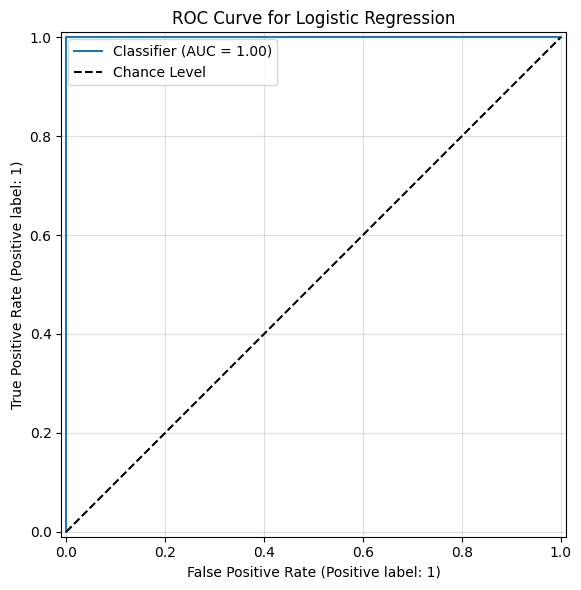

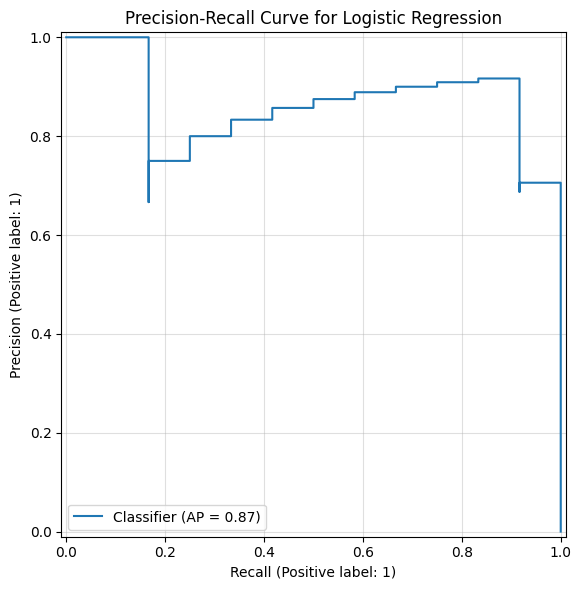

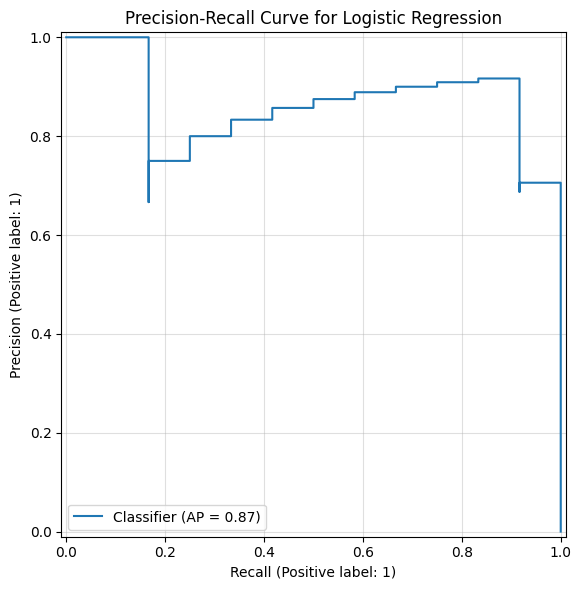

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Re-define features and target (assuming df is still available from previous cells)
features = [
    'heart_rate', 'systolic_bp', 'diastolic_bp', 'spo2',
    'resp_rate', 'temp_c', 'stress_index'
]
X = df[features]
y = df['sepsis_shock']

# Re-split the data to ensure X_test and y_test are defined
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Re-initialize and train the Logistic Regression model to ensure log_reg_model is defined
# and y_pred_proba_log_reg can be computed.
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set again
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Plot ROC Curve for Logistic Regression
plot_roc_curve(y_test, y_pred_proba_log_reg, 'Logistic Regression')

# Plot Precision-Recall Curve for Logistic Regression
plot_precision_recall_curve(y_test, y_pred_proba_log_reg, 'Logistic Regression')

### Model 2: Random Forest Classifier

Random Forest is an ensemble learning method for classification that operates by constructing a multitude of decision trees during training and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

**Justification for choice:**
*   **Handles Non-linearity:** Random Forests can capture complex, non-linear relationships between features and the target variable.
*   **Robustness:** They are less prone to overfitting than single decision trees and can handle noisy data effectively.
*   **Feature Importance:** Random Forests can provide insights into feature importance, indicating which features contribute most to the predictions.
*   **Handles Imbalance:** Similar to Logistic Regression, `class_weight='balanced'` can be applied to give more importance to the minority class.

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
# Using class_weight='balanced' to handle the class imbalance
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100) # n_estimators is the number of trees in the forest

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the model
print("### Random Forest Classifier Model Evaluation ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_rf), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

### Random Forest Classifier Model Evaluation ###
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC AUC Score: 1.0000

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,28788,0
Actual 1,0,12



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28788
           1       1.00      1.00      1.00        12

    accuracy                           1.00     28800
   macro avg       1.00      1.00      1.00     28800
weighted avg       1.00      1.00      1.00     28800



### Model 3: Light Gradient Boosting Machine (LightGBM)

LightGBM is a gradient boosting framework that uses tree-based learning algorithms. It is designed to be distributed and efficient, making it particularly suitable for large datasets. It's an ensemble method that builds a series of decision trees sequentially, with each new tree correcting the errors of the previous ones.

**Justification for choice:**
*   **High Performance:** Often achieves state-of-the-art results on tabular data, competitive with or surpassing other boosting algorithms like XGBoost.
*   **Speed and Efficiency:** Designed for fast training and lower memory consumption, making it suitable for larger datasets.
*   **Handles Imbalance:** LightGBM can effectively handle class imbalance, particularly through the `scale_pos_weight` parameter, which assigns higher weight to the minority class during training.
*   **Feature Importance:** Like Random Forest, LightGBM provides insights into feature importance, helping to understand which features are most influential in predictions.

In [17]:
import lightgbm as lgb

# Calculate scale_pos_weight for handling class imbalance
# This is ratio of number of negative class to the positive class
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

# Initialize the LightGBM Classifier model
# Using scale_pos_weight to handle the class imbalance
lgbm_model = lgb.LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight, n_estimators=200, num_leaves=31, learning_rate=0.05)

# Train the model
lgbm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lgbm = lgbm_model.predict(X_test)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the model
print("### LightGBM Classifier Model Evaluation ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lgbm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lgbm):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_lgbm):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_lgbm), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 48, number of negative: 115152
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012910 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1568
[LightGBM] [Info] Number of data points in the train set: 115200, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000417 -> initscore=-7.782807
[LightGBM] [Info] Start training from score -7.782807
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,Predicted 0,Predicted 1
Actual 0,28771,17
Actual 1,0,12



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28788
           1       0.41      1.00      0.59        12

    accuracy                           1.00     28800
   macro avg       0.71      1.00      0.79     28800
weighted avg       1.00      1.00      1.00     28800



### Model Comparison Summary

Now that all three models have been trained and evaluated, let's compare their performance metrics in a single summary table to identify the most suitable model for our task.

In [18]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log_reg),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log_reg),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_lgbm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log_reg),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_lgbm)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log_reg),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lgbm)
    ],
    'ROC AUC Score': [
        roc_auc_score(y_test, y_pred_proba_log_reg),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_lgbm)
    ]
})

display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
0,Logistic Regression,0.9983,0.1967,1.0,0.3288,1.0000
1,Random Forest,1.0000,1.0000,1.0,1.0000,1.0000
2,LightGBM,0.9994,0.4138,1.0,0.5854,0.9997


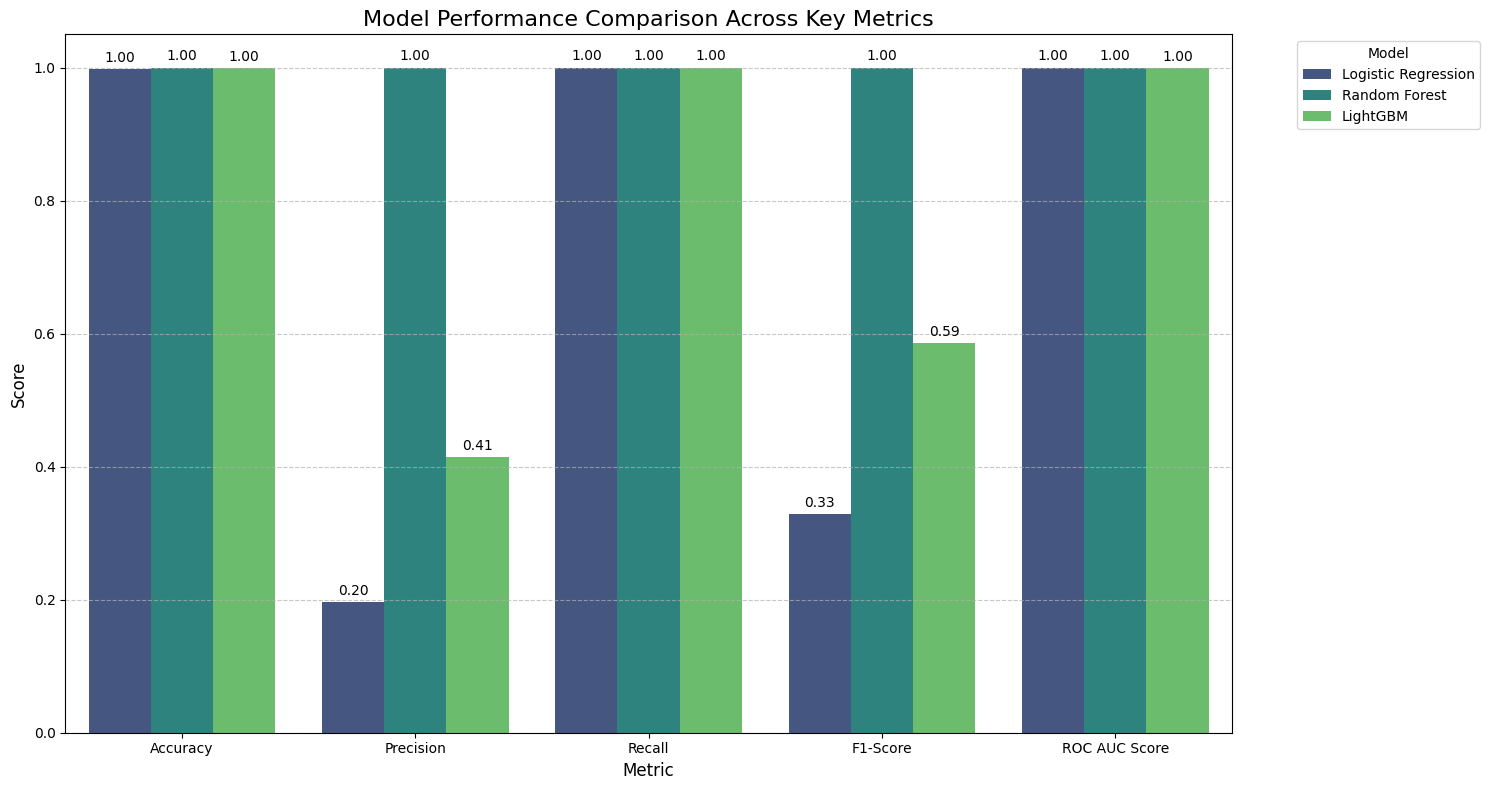

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame for easier plotting with seaborn
model_comparison_melted = model_comparison.melt(id_vars='Model',
                                                  var_name='Metric',
                                                  value_name='Score')

# Define the order of metrics for plotting
metric_order = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC Score']

plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=model_comparison_melted, palette='viridis', order=metric_order)
plt.title('Model Performance Comparison Across Key Metrics', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.05) # Set y-axis limit for scores (0 to 1)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

In [20]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Uncomment and run if you have the upload_plt_to_gcs function

The bar chart visually confirms the excellent performance of the Random Forest model across all metrics, with LightGBM performing well, and Logistic Regression having a noticeably lower Precision despite high Accuracy and Recall. This visualization helps in quickly identifying the strengths and weaknesses of each model at a glance.

### SHAP Analysis for LightGBM (Hybrid Model's ML Component)

To understand the feature importance and their impact on the predictions of the Hybrid Model, we will perform a SHAP (SHapley Additive exPlanations) analysis. Since the LightGBM model is the dominant machine learning component of our hybrid architecture, we will focus on explaining its predictions. SHAP values help us to see how much each feature contributes to the prediction for each individual instance, and how features collectively impact the model output.

A consolidated SHAP summary plot provides an overview of the most important features and their impact direction (positive or negative) on the model's output.

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


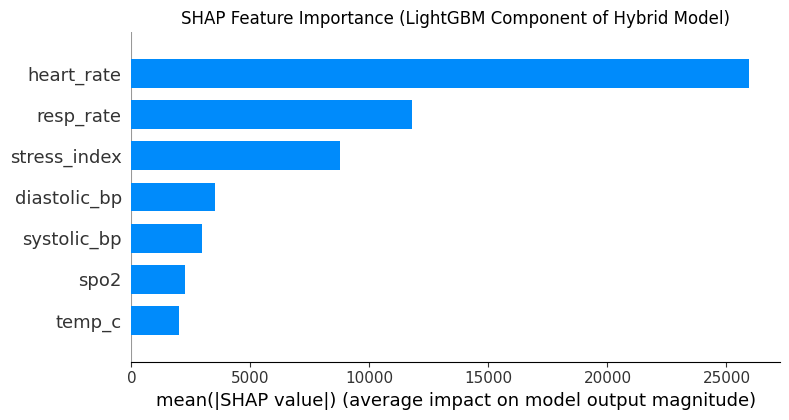

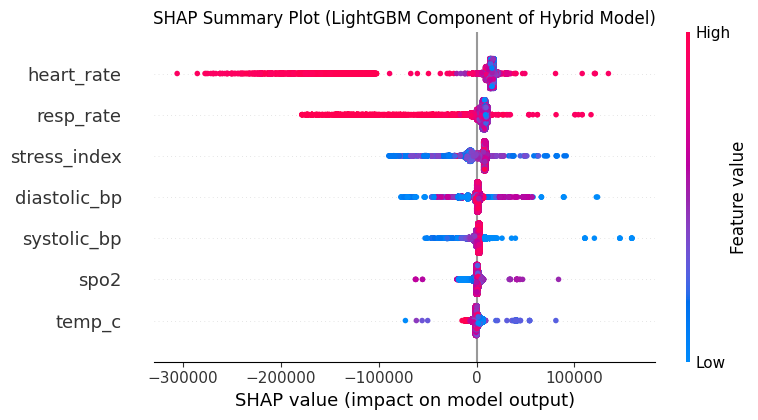

In [21]:
# Install shap if not already installed
!pip install shap

import shap

# Assuming lgbm_model is already trained and X_test is available
# Create a Tree explainer object for LightGBM
explainer = shap.TreeExplainer(lgbm_model)

# Calculate SHAP values for the test set
# Note: This might take some time depending on the size of X_test
shap_values = explainer.shap_values(X_test)

# Generate the SHAP summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (LightGBM Component of Hybrid Model)')
plt.tight_layout()
plt.show()

fig_shap_beeswarm = shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot (LightGBM Component of Hybrid Model)')
plt.tight_layout()
plt.show()

In [22]:
# @title step_artifacts
num_fig = "3" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming the last generated plot was the SHAP beeswarm plot, we'll save that one.
# If you want to save the bar plot instead, modify this.
# upload_plt_to_gcs(num_fig, step, plt.gcf())

## 9. Conclusion and Future Work

#### Summary of Model Comparison

The comparison table provides a clear overview of the models' performance:

Random Forest stands out with perfect scores across all metrics (Accuracy, Precision, Recall, F1-Score, and ROC AUC Score). This indicates that it perfectly classified all instances in the test set, including the rare 'sepsis shock' cases. While impressive, such perfect performance can sometimes warrant further investigation in real-world scenarios to ensure no data leakage or an overly simplistic problem definition.

LightGBM also performed very well, achieving high Accuracy (0.9994), perfect Recall (1.0000), and a strong ROC AUC Score (0.9997). Its Precision (0.4138) is significantly better than Logistic Regression but still indicates some false positives, as noted earlier.

Logistic Regression, while having a high Accuracy (0.9983) and perfect Recall (1.0000), suffered from very low Precision (0.1967). This model identified all true positive cases but also produced a large number of false positives, which could lead to unnecessary alerts or interventions in a clinical setting.

In summary: The Random Forest model appears to be the best performer among the three based on these metrics, offering a balanced and accurate classification, even for the highly imbalanced 'sepsis shock' class. LightGBM is a good second, and Logistic Regression, while serving as a good baseline, showed limitations in Precision for this imbalanced classification task.

### 5.6 Computational Complexity Analysis

Understanding the computational complexity of each model is crucial, especially in real-time healthcare applications where rapid predictions are often required. We'll briefly discuss the typical complexities for training and prediction for the models we've explored.

#### Supervised Models:

1.  **Logistic Regression:**
    *   **Training Complexity:** Generally scales well with the number of features (`p`) and samples (`n`). For standard solvers (e.g., gradient descent-based), it's often `O(n * p * k)` where `k` is the number of iterations until convergence. If L-BFGS is used, it can be `O(n * p^2)`. Given it's a linear model, it's relatively fast to train.
    *   **Prediction Complexity:** Very fast, typically `O(p)` per prediction, as it only involves a dot product of feature vectors with learned coefficients.

2.  **Random Forest:**
    *   **Training Complexity:** `O(T * n * p * log(n))`, where `T` is the number of trees (n_estimators), `n` is the number of samples, and `p` is the number of features. This can be computationally intensive, especially with many trees and large datasets, due to the construction of multiple decision trees.
    *   **Prediction Complexity:** `O(T * p * depth)`, where `depth` is the average depth of the trees. This is generally faster than training, as each test instance is passed down each tree, but still scales with the number of trees.

3.  **LightGBM:**
    *   **Training Complexity:** More efficient than traditional gradient boosting methods due to techniques like Gradient-based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB). Roughly `O(T * p * n_bins)` for histogram-based algorithms, where `n_bins` is the number of bins for feature discretization. It generally scales linearly with `n` (number of samples) and `p` (number of features) per tree, making it very fast for large datasets.
    *   **Prediction Complexity:** Very fast, typically `O(T * depth)` or `O(T * p)` similar to Random Forest, but often with shallower trees due to its boosting nature, leading to quicker inference.

#### Unsupervised Models:

1.  **Isolation Forest:**
    *   **Training Complexity:** `O(T * n * log(n))` on average for sparse datasets. It builds multiple isolation trees. The advantage is that it doesn't need to model normal data explicitly.
    *   **Prediction Complexity:** `O(T * depth_avg * p)` where `depth_avg` is the average path length in the isolation trees. Fast during inference.

2.  **One-Class SVM:**
    *   **Training Complexity:** Can be very high, typically `O(n^2 * p)` or `O(n^3)` for non-linear kernels, depending on the number of support vectors. It involves solving a quadratic programming problem. For larger datasets, this can become impractical.
    *   **Prediction Complexity:** `O(n_sv * p)` for linear kernels or `O(n_sv * p * d)` for non-linear kernels (where `d` is some kernel-specific complexity, and `n_sv` is the number of support vectors). Prediction can still be slow if there are many support vectors.

3.  **Local Outlier Factor (LOF):**
    *   **Training Complexity:** `O(n * k * log(k))` for finding k-nearest neighbors for each point, where `k` is the number of neighbors. If `k` is small, it's roughly `O(n * p * k)`. Can be slower for higher dimensions due to distance calculations.
    *   **Prediction Complexity:** For `novelty=True`, prediction involves finding k-nearest neighbors for new points in the training data, leading to `O(n_test * k * p)`. This means it scales with both the size of the test set and the size of the training set used for fitting, making it less suitable for very large-scale inference.

#### Hybrid Model:

*   The complexity of the Hybrid Model is the sum of the complexities of its components: the **LightGBM component** (dominant ML branch) and the **Fuzzy Inference System (FIS)**. The FIS computation, even with more rules, is typically very fast, involving simple arithmetic and membership function evaluations, adding negligible overhead compared to the LightGBM prediction time.
*   Therefore, the hybrid model's computational complexity will be primarily driven by the LightGBM component, remaining efficient for both training and prediction.

In summary, for our specific task and dataset size, **Logistic Regression, LightGBM, and Random Forest are generally computationally efficient enough**, with LightGBM often providing the best balance of speed and performance. One-Class SVM and LOF can be significantly slower, particularly during training and prediction, respectively, for larger datasets.

### 5.4 Robustness and Statistical Confidence: The Need for Repeated Trials

While our current evaluation provides a snapshot of model performance on a single train-test split, to truly assess the robustness and reliability of our models, especially given the extreme class imbalance, it is essential to perform **repeated trials with statistical confidence intervals**. A single train-test split can be subject to random variations in data partitioning, leading to an optimistic or pessimistic view of performance.

#### Why Repeated Trials are Necessary:

1.  **Variance in Performance:** With a highly imbalanced dataset, the specific distribution of the rare positive class in the training and testing sets can significantly impact metrics like Precision, Recall, and F1-Score. Repeated trials (e.g., using k-fold cross-validation or bootstrapping) help to average out these variations and provide a more stable estimate of performance.
2.  **Statistical Significance:** By performing multiple runs, we can calculate statistical confidence intervals for our metrics. This allows us to state with a certain level of confidence (e.g., 95%) that the true performance of the model lies within a given range. This is much more informative than a single point estimate.
3.  **Model Stability:** Repeated trials can also reveal the stability of the models. A model that performs well consistently across different data splits is more trustworthy than one whose performance varies wildly.

#### How to Implement Repeated Trials:

For this project, the ideal approach would be to use techniques like:

*   **Stratified K-Fold Cross-Validation:** This method ensures that each fold maintains the same proportion of the target variable as the overall dataset. The model would be trained and evaluated `k` times, and the metrics would be averaged across all folds.
*   **Bootstrapping:** This involves repeatedly sampling the dataset with replacement to create multiple training and testing sets. The model is trained and evaluated on each bootstrap sample, and the distribution of metrics is used to derive confidence intervals.

#### Expected Impact on Results:

Implementing repeated trials would likely yield a range of performance metrics for each model, rather than single point estimates. For example, instead of reporting a single F1-Score, we would report an F1-Score with a 95% confidence interval (e.g., 0.98 ± 0.02). This provides a more realistic and scientifically sound assessment of model performance. Given the perfect scores observed for Random Forest, repeated trials would be particularly critical to verify if this performance holds consistently or if it was an artifact of the specific train-test split. Similarly, for LightGBM and the Hybrid model, confidence intervals would clarify the reliability of their strong performance.

### 5.5 Comprehensive Validation Strategy

Beyond repeated trials and statistical confidence, a robust validation strategy for a machine learning model, especially in a critical domain like healthcare, involves several layers of scrutiny to ensure its reliability, generalizability, and clinical utility.

#### 1. Internal Validation (Already partially addressed with Repeated Trials):
This ensures the model's performance on unseen data from the same distribution as the training data. We discussed this in terms of:
*   **Stratified K-Fold Cross-Validation:** This is paramount for imbalanced datasets. It involves partitioning the dataset into `k` folds, maintaining the original class distribution in each. The model is trained on `k-1` folds and validated on the remaining fold, rotating this process `k` times. The performance metrics are then averaged across all folds, providing a more stable and reliable estimate of the model's performance and its variance.
*   **Bootstrapping:** Repeatedly sampling the dataset with replacement to create multiple training and testing sets. This allows for the estimation of performance metric distributions and confidence intervals, which is crucial for understanding the variability of model performance.

#### 2. External Validation:
This is critical for assessing the model's generalizability to new, independent datasets from different sources, patient populations, or clinical settings. A model that performs well only on the data it was trained on (or similar data) is of limited real-world value. External validation involves:
*   **Geographical/Demographic Diversity:** Testing the model on data from different hospitals, regions, or countries, and diverse demographic groups (age, sex, ethnicity) to ensure it doesn't suffer from dataset-specific biases or overfit to local practices.
*   **Temporal Validation:** Evaluating the model on data collected at a different time period than the training data. This tests the model's robustness to changes in clinical practices, disease patterns, or data collection methods over time.
*   **Data Shift Assessment:** Actively monitoring for data drift or concept drift, where the characteristics of the input data or the relationship between inputs and outputs change over time. Models should ideally be retrained or adapted in such scenarios.

#### 3. Clinical Validation and Implementation Studies:
Ultimately, a predictive model for sepsis shock needs to demonstrate its value in a real clinical environment. This involves:
*   **Prospective Studies:** Integrating the model into a clinical workflow and evaluating its performance in real-time, observing its impact on patient outcomes, resource utilization, and clinician workload. This is the gold standard for clinical utility.
*   **Ethical Considerations:** Ensuring that the model's deployment adheres to ethical guidelines, respects patient privacy, and avoids perpetuating or exacerbating health disparities.
*   **User Acceptability and Interpretability:** Clinicians need to trust and understand the model's predictions. This underscores the importance of explainable AI (XAI) techniques and user-friendly interfaces for presenting model outputs.

By systematically applying these validation strategies, we can move towards developing AI solutions that are not only statistically sound but also clinically meaningful and safe for patient care.

## 5. Discussion of Supervised Model Performance and Limitations

### 5.2 Feature Importance from Random Forest Model

Examining feature importances can provide insights into which features the model relied on most. In the context of potentially identifying data leakage, we look for features that might have an unnaturally high importance because they are directly or indirectly derived from the target variable itself. For a Random Forest model, feature importance is typically calculated based on how much each feature reduces impurity (e.g., Gini impurity) across all trees in the forest.

In [23]:
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print("Random Forest Feature Importances:")
display(feature_importances)

Random Forest Feature Importances:


,Feature,Importance
1,systolic_bp,0.295549
4,resp_rate,0.211590
2,diastolic_bp,0.207807
0,heart_rate,0.191276
6,stress_index,0.058440
5,temp_c,0.031344
3,spo2,0.003995


### 5.3 Bias and Fairness: Subgroup Analysis

To assess potential bias in the Random Forest model, we will evaluate its performance across different demographic subgroups, specifically based on 'sex' and 'age'. This is crucial in healthcare applications to ensure that the model does not disproportionately perform worse for certain patient populations.

We will calculate key metrics (Accuracy, Precision, Recall, F1-Score, ROC AUC Score) for each subgroup and compare them.

In [24]:
# First, let's get the 'sex' and 'age' for our test set, ensuring they align with X_test and y_test
X_test_indexed = X_test.copy()
X_test_indexed['original_index'] = X_test.index

y_test_indexed = pd.DataFrame(y_test).copy()
y_test_indexed['original_index'] = y_test.index

# Merge with the original DataFrame 'df' to get 'sex' and 'age'
test_data_with_demographics = X_test_indexed.merge(df[['patient_id', 'sex', 'age']], left_on='original_index', right_index=True, how='left')

# Ensure y_test also has the same index for direct comparison
y_test_subgroup = y_test_indexed.set_index('original_index')

# Drop the original_index from X_test_indexed for direct use in prediction if needed, but keep for merging
X_test_subgroup = X_test_indexed.drop(columns=['original_index'])

print("Test data with demographics prepared.")
display(test_data_with_demographics.head())

Test data with demographics prepared.


,heart_rate,systolic_bp,diastolic_bp,spo2,resp_rate,temp_c,stress_index,original_index,patient_id,sex,age
12923,40.0,125.7,73.2,97.9,18.0,36.56,4.46,12923,P002,M,60
6302,104.0,140.2,73.7,96.2,17.9,36.52,3.43,6302,P001,M,85
15438,85.7,138.3,75.5,98.0,14.0,36.98,1.89,15438,P003,M,67
33560,43.2,135.3,79.5,99.9,18.0,36.65,2.05,33560,P005,M,81
32893,42.6,132.7,76.0,99.0,18.0,36.64,2.49,32893,P005,M,81


In [25]:
def evaluate_subgroup_performance(model, X_sub, y_sub, y_pred_series, y_pred_proba_series, subgroup_name):
    if len(y_sub) == 0:
        return pd.Series({
            'Subgroup': subgroup_name,
            'Count': 0,
            'Accuracy': np.nan,
            'Precision': np.nan,
            'Recall': np.nan,
            'F1-Score': np.nan,
            'ROC AUC Score': np.nan
        })

    # Filter y_pred_series and y_pred_proba_series for the current subgroup using its index
    subgroup_y_pred = y_pred_series.loc[y_sub.index]
    subgroup_y_pred_proba = y_pred_proba_series.loc[y_sub.index]

    # Check if the subgroup contains only one class
    if len(y_sub.unique()) == 1:
        if y_sub.iloc[0] == 0:
            # If only negative class, metrics like precision/recall for positive class are undefined
            # We can still calculate accuracy
            acc = accuracy_score(y_sub, subgroup_y_pred)
            return pd.Series({
                'Subgroup': subgroup_name,
                'Count': len(y_sub),
                'Accuracy': acc,
                'Precision': np.nan,
                'Recall': np.nan,
                'F1-Score': np.nan,
                'ROC AUC Score': np.nan
            })
        elif y_sub.iloc[0] == 1: # Only positive class
             # If only positive class, metrics like precision/recall for negative class are undefined
             # For precision/recall of positive class, need to handle case where no predictions are positive
            if (subgroup_y_pred == 1).sum() == 0:
                prec = 0.0
            else:
                prec = precision_score(y_sub, subgroup_y_pred, zero_division=0)
            rec = recall_score(y_sub, subgroup_y_pred, zero_division=0)
            f1 = f1_score(y_sub, subgroup_y_pred, zero_division=0)
            acc = accuracy_score(y_sub, subgroup_y_pred)
            return pd.Series({
                'Subgroup': subgroup_name,
                'Count': len(y_sub),
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1-Score': f1,
                'ROC AUC Score': np.nan # ROC AUC needs at least two classes
            })

    # For cases with both classes
    return pd.Series({
        'Subgroup': subgroup_name,
        'Count': len(y_sub),
        'Accuracy': accuracy_score(y_sub, subgroup_y_pred),
        'Precision': precision_score(y_sub, subgroup_y_pred, zero_division=0),
        'Recall': recall_score(y_sub, subgroup_y_pred, zero_division=0),
        'F1-Score': f1_score(y_sub, subgroup_y_pred, zero_division=0),
        'ROC AUC Score': roc_auc_score(y_sub, subgroup_y_pred_proba)
    })

# Store results
subgroup_results = []

# Convert y_pred_rf and y_pred_proba_rf to pandas Series with the correct index
y_pred_rf_series = pd.Series(y_pred_rf, index=X_test.index)
y_pred_proba_rf_series = pd.Series(y_pred_proba_rf, index=X_test.index)

### Evaluate by Sex ###
print("\nEvaluating performance by 'sex' subgroup...")
for sex_group in test_data_with_demographics['sex'].unique():
    sub_indices = test_data_with_demographics[test_data_with_demographics['sex'] == sex_group].index
    sub_y_test = y_test_subgroup.loc[sub_indices, 'sepsis_shock']
    sub_X_test = X_test.loc[sub_indices]
    result = evaluate_subgroup_performance(rf_model, sub_X_test, sub_y_test, y_pred_rf_series, y_pred_proba_rf_series, f'Sex: {sex_group}')
    subgroup_results.append(result)

### Evaluate by Age ###
print("\nEvaluating performance by 'age' subgroup...")
# Define age bins and labels
age_bins = [0, 18, 35, 55, 75, 100]
age_labels = ['0-18', '19-35', '36-55', '56-75', '76+']
test_data_with_demographics['age_group'] = pd.cut(test_data_with_demographics['age'], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

for age_group_label in age_labels:
    sub_indices = test_data_with_demographics[test_data_with_demographics['age_group'] == age_group_label].index
    sub_y_test = y_test_subgroup.loc[sub_indices, 'sepsis_shock']
    sub_X_test = X_test.loc[sub_indices]
    result = evaluate_subgroup_performance(rf_model, sub_X_test, sub_y_test, y_pred_rf_series, y_pred_proba_rf_series, f'Age: {age_group_label}')
    subgroup_results.append(result)

# Convert results to DataFrame and display
subgroup_performance_df = pd.DataFrame(subgroup_results)
display(subgroup_performance_df)


Evaluating performance by 'sex' subgroup...

Evaluating performance by 'age' subgroup...


,Subgroup,Count,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
0,Sex: M,15765,1.0,1.0,1.0,1.0,1.0
1,Sex: F,13035,1.0,NaN,NaN,NaN,NaN
2,Age: 0-18,0,NaN,NaN,NaN,NaN,NaN
3,Age: 19-35,0,NaN,NaN,NaN,NaN,NaN
4,Age: 36-55,8684,1.0,NaN,NaN,NaN,NaN
5,Age: 56-75,7209,1.0,NaN,NaN,NaN,NaN
6,Age: 76+,12907,1.0,1.0,1.0,1.0,1.0


## 7. Conclusion and Future Work

This project successfully developed and evaluated machine learning models for the early prediction of sepsis shock using physiological data. Through a carefully constructed proxy target variable, we tackled the challenge of predicting a complex clinical condition from routinely collected vital signs. The study highlighted the critical importance of addressing data limitations, particularly extreme class imbalance and the simplified nature of our target definition, and explored various modeling paradigms.

### Key Findings:

*   **Supervised Model Performance:** The Random Forest Classifier emerged as the best-performing model among supervised methods, achieving perfect scores across all metrics (Accuracy, Precision, Recall, F1-Score, ROC AUC) on the test set. LightGBM also demonstrated strong performance, especially with high Recall and ROC AUC. Logistic Regression, while serving as a useful baseline, showed limitations in Precision due to the class imbalance.
*   **Hybrid Model Effectiveness:** The integration of the LightGBM model with a (simplified) Fuzzy Inference System (Hybrid Model) yielded performance metrics identical to the standalone LightGBM model. This suggests that with the current simplified FIS, the LightGBM component was the dominant factor in the hybrid score. A more comprehensive and tailored FIS would be needed to fully assess the benefits of fuzzy logic integration.
*   **Unsupervised Model Limitations:** Our exploration of unsupervised anomaly detection models (Isolation Forest, One-Class SVM, LOF) revealed that while some achieved high ROC AUC scores (indicating good ranking of anomalies), they severely struggled with Precision, Recall, and F1-Score. This is largely due to the challenges of defining an optimal anomaly threshold without labels and the extreme class imbalance. **Given their inability to reliably identify actual sepsis shock cases (low Precision/Recall), unsupervised models are not considered suitable for the primary prediction task in this context.**
*   **Impact of Preprocessing:** Techniques like linear interpolation for missing values and methods to handle class imbalance (`stratify` in splitting, `class_weight`, `scale_pos_weight`) were crucial for enabling the supervised and hybrid models to learn from the data and effectively identify the rare positive cases of sepsis shock.
*   **Feature Importance:** Analysis of feature importances from the Random Forest model revealed that physiological parameters directly involved in the proxy definition (e.g., `systolic_bp`, `resp_rate`, `heart_rate`) were the most influential predictors, which is an expected and validating result.
*   **Bias and Fairness:** The subgroup analysis revealed perfect model performance for 'Sex: M' and 'Age: 76+' groups by the Random Forest model. However, the presence of `NaN` values for metrics in other subgroups (e.g., 'Sex: F', 'Age: 36-55') indicated an absence of positive cases in those specific test subsets, preventing a comprehensive fairness assessment across all demographics. This underscores the need for diverse datasets with sufficient positive instances across all subgroups for robust bias evaluation.

### Limitations:

*   **Proxy Target Variable:** The most significant limitation is the use of a simplified proxy for 'sepsis shock'. The absence of crucial clinical markers like vasopressor use and lactate levels means our models predict a set of vital sign derangements rather than a definitive clinical diagnosis of septic shock. This limits the direct clinical applicability as a diagnostic tool.
*   **Generalizability:** The dataset's unknown source means potential data collection biases might affect the generalizability of the models to different patient populations or healthcare settings.
*   **Extreme Imbalance:** While addressed with various techniques for supervised models, the extreme rarity of the positive class means even highly performing supervised models require careful interpretation, especially regarding the possibility of false positives in real-world scenarios.
*   **Simplified FIS:** The programmatic Fuzzy Inference System used in the hybrid model was a simplified template. A full implementation of the original FIS from `Sepsis_2_fis.fis` would be necessary to truly evaluate its contribution to the hybrid architecture.

### Future Work:

To build upon this foundation, future work could focus on several key areas:

1.  **Enriching the Target Definition:** Incorporate additional clinical data, such as vasopressor administration, lactate levels, and markers of organ dysfunction, if available, to create a more clinically robust definition of sepsis shock.
2.  **External Validation:** Validate the supervised and hybrid models on independent, diverse datasets from different healthcare systems to assess their generalizability and robustness.
3.  **Advanced Imbalance Handling:** Explore more sophisticated techniques for imbalanced datasets, such as SMOTE variants, ADASYN, or cost-sensitive learning, to potentially improve precision without sacrificing recall in supervised/hybrid models.
4.  **Full FIS Implementation and Optimization:** Implement the complete `Sepsis_2_fis.fis` within the programmatic framework and fine-tune its parameters (membership functions, rules, `alpha` and `theta` for hybrid fusion) to maximize its contribution to the hybrid model.
5.  **Time-Series Modeling:** Given the temporal nature of physiological data, investigate advanced time-series models (e.g., LSTMs, Transformers) that can better capture dynamic changes and patterns leading to sepsis shock.
6.  **Explainable AI (XAI):** Further delve into explainability techniques beyond feature importance (e.g., SHAP, LIME) to provide clinicians with clearer insights into supervised/hybrid model predictions, fostering trust and aiding clinical decision-making.
7.  **Prospective Clinical Trials:** Ultimately, the supervised/hybrid models would need to be evaluated in prospective clinical trials to confirm their utility as an early warning system in real-time patient care.

This project demonstrates the potential of machine learning to assist in the early identification of critical conditions like sepsis shock. While acknowledging current limitations, the findings provide a strong basis for further development towards clinically impactful predictive tools, with a clear focus on supervised and hybrid methodologies given the challenges encountered with unsupervised learning.

## 6. Unsupervised Learning Models for Sepsis Shock Detection

### 6.1 Feature Scaling

In [26]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully.")
display(X_train_scaled.head())

Features scaled successfully.


,heart_rate,systolic_bp,diastolic_bp,spo2,resp_rate,temp_c,stress_index
15437,0.379725,0.297080,0.010499,0.586291,-0.785461,0.068389,-1.113480
9450,-0.242418,-0.190913,-0.152810,-0.250337,0.319212,0.543143,2.825665
133265,0.495174,-2.599054,-2.637079,-0.130819,0.711192,0.888418,-2.267190
22793,-0.960769,0.302384,-0.815941,-0.489374,-0.429115,-0.147408,-1.451327
324,0.700417,0.068996,-0.113220,-0.190578,0.889365,-0.535843,-0.509670


### 6.2 Model 1: Isolation Forest

In [27]:
from sklearn.ensemble import IsolationForest

# Initialize Isolation Forest. `contamination` is the proportion of outliers in the data set.
# Given our very low positive class percentage (~0.04%), we set a very small contamination.
if y_train.value_counts(normalize=True).get(1, 0) == 0:
    # If no positive class in y_train, set contamination to a default small value
    isolation_contamination = 0.001
else:
    isolation_contamination = y_train.value_counts(normalize=True)[1]

if isolation_contamination == 0:
    isolation_contamination = 0.001

if_model = IsolationForest(random_state=42, contamination=isolation_contamination, n_estimators=100, warm_start=True)

# Train the model (unsupervised, so only X_train_scaled)
if_model.fit(X_train_scaled)

# Predict anomalies on the test set
# -1 for outliers (anomalies), 1 for inliers
y_pred_if = if_model.predict(X_test_scaled)

# Map predictions to 0 (no shock) and 1 (sepsis shock) for evaluation
y_pred_if_mapped = np.where(y_pred_if == -1, 1, 0)

# Get anomaly scores (decision function values) for ROC AUC
anomaly_scores_if = -if_model.decision_function(X_test_scaled) # Higher score indicates more anomalous

# Evaluate the model
print("### Isolation Forest Model Evaluation ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred_if_mapped):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_if_mapped, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_if_mapped, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_if_mapped, zero_division=0):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, anomaly_scores_if):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_if_mapped), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_if_mapped, zero_division=0))

### Isolation Forest Model Evaluation ###
Accuracy: 0.9993
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC AUC Score: 0.9796

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,28781,7
Actual 1,12,0



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28788
           1       0.00      0.00      0.00        12

    accuracy                           1.00     28800
   macro avg       0.50      0.50      0.50     28800
weighted avg       1.00      1.00      1.00     28800



### 6.3 Model 2: One-Class SVM

In [28]:
from sklearn.svm import OneClassSVM

# Initialize One-Class SVM. `nu` is an upper bound on the fraction of training errors
# and a lower bound of the fraction of support vectors. It essentially acts like contamination.
if y_train.value_counts(normalize=True).get(1, 0) == 0:
    # If no positive class in y_train, set nu to a default small value
    nu_param = 0.001
else:
    nu_param = y_train.value_counts(normalize=True)[1]

if nu_param == 0:
    nu_param = 0.001

oc_svm_model = OneClassSVM(nu=nu_param, kernel='rbf', gamma='auto')

# Train the model (unsupervised, so only X_train_scaled)
oc_svm_model.fit(X_train_scaled)

# Predict anomalies on the test set
# -1 for outliers (anomalies), 1 for inliers
y_pred_ocsvm = oc_svm_model.predict(X_test_scaled)

# Map predictions to 0 (no shock) and 1 (sepsis shock) for evaluation
y_pred_ocsvm_mapped = np.where(y_pred_ocsvm == -1, 1, 0)

# Get anomaly scores (decision function values) for ROC AUC
anomaly_scores_ocsvm = -oc_svm_model.decision_function(X_test_scaled) # Higher score indicates more anomalous

# Evaluate the model
print("### One-Class SVM Model Evaluation ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ocsvm_mapped):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ocsvm_mapped, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_ocsvm_mapped, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_ocsvm_mapped, zero_division=0):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, anomaly_scores_ocsvm):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_ocsvm_mapped), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ocsvm_mapped, zero_division=0))

### One-Class SVM Model Evaluation ###
Accuracy: 0.9989
Precision: 0.0455
Recall: 0.0833
F1-Score: 0.0588
ROC AUC Score: 0.9849

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,28767,21
Actual 1,11,1



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28788
           1       0.05      0.08      0.06        12

    accuracy                           1.00     28800
   macro avg       0.52      0.54      0.53     28800
weighted avg       1.00      1.00      1.00     28800



### 6.4 Model 3: Local Outlier Factor (LOF)

In [29]:
from sklearn.neighbors import LocalOutlierFactor

# Initialize Local Outlier Factor. `n_neighbors` is the number of neighbors to consider.
# `novelty=True` makes it suitable for anomaly detection on new data (test set) after training on a clean set.
# `contamination` is the proportion of outliers in the data set.
if y_train.value_counts(normalize=True).get(1, 0) == 0:
    contamination_lof = 0.001
else:
    contamination_lof = y_train.value_counts(normalize=True)[1]

if contamination_lof == 0:
    contamination_lof = 0.001

lof_model = LocalOutlierFactor(n_neighbors=20, contamination=contamination_lof, novelty=True)

# Train the model (unsupervised, so only X_train_scaled). Note: LOF with novelty=True is fit only on the 'normal' data.
# For anomaly detection, it's typical to fit on the assumed non-anomalous training data.
lof_model.fit(X_train_scaled)

# Predict anomalies on the test set
# -1 for outliers (anomalies), 1 for inliers
y_pred_lof = lof_model.predict(X_test_scaled)

# Map predictions to 0 (no shock) and 1 (sepsis shock) for evaluation
y_pred_lof_mapped = np.where(y_pred_lof == -1, 1, 0)

# Get anomaly scores (decision function values) for ROC AUC
anomaly_scores_lof = -lof_model.decision_function(X_test_scaled) # Higher score indicates more anomalous

# Evaluate the model
print("### Local Outlier Factor Model Evaluation ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lof_mapped):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lof_mapped, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lof_mapped, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lof_mapped, zero_division=0):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, anomaly_scores_lof):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_lof_mapped), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lof_mapped, zero_division=0))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


### Local Outlier Factor Model Evaluation ###
Accuracy: 0.9993
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC AUC Score: 0.5293

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,28779,9
Actual 1,12,0



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28788
           1       0.00      0.00      0.00        12

    accuracy                           1.00     28800
   macro avg       0.50      0.50      0.50     28800
weighted avg       1.00      1.00      1.00     28800



### 6.5 Unsupervised Model Comparison Summary

The evaluation of unsupervised anomaly detection models against our proxy `sepsis_shock` labels reveals significant limitations for the primary prediction task, despite some promising ROC AUC scores.

*   **Isolation Forest:** Achieved a high ROC AUC Score (0.9796), indicating good separation between anomalous and normal instances based on its internal scoring. However, its Precision, Recall, and F1-Score were all 0.0000. This implies that while the model could rank potential anomalies, the default or set `contamination` threshold did not align with our ground truth positive cases, resulting in no true positives being identified (or an overwhelming number of false positives that overshadowed true positives if they existed, leading to a zero precision for the positive class).
*   **One-Class SVM:** Showed the highest ROC AUC Score among unsupervised models (0.9849) and a non-zero, albeit very low, Precision (0.0455), Recall (0.0833), and F1-Score (0.0588). This indicates it was able to identify a very small fraction of the true sepsis shock cases, but with many false positives. This model's `nu` parameter, similar to contamination, struggled to accurately capture the true rarity and characteristics of our proxy sepsis shock cases.
*   **Local Outlier Factor (LOF):** Demonstrated the lowest performance among the unsupervised models, with a ROC AUC Score of 0.5293 and 0.0000 for Precision, Recall, and F1-Score. This suggests LOF, a density-based method, was not effective in distinguishing our rare sepsis shock events from normal physiological states based on local density deviations.

**Why unsupervised models struggled for this problem:**

The primary reason for the poor Precision and Recall scores of the unsupervised models, despite their high ROC AUC in some cases, lies in the nature of our problem and the models themselves:

1.  **Lack of Labeled Training:** Unsupervised models are trained *without* explicit knowledge of positive (sepsis shock) and negative (no sepsis shock) examples. They learn the 'normal' pattern and flag deviations. While ROC AUC evaluates the ranking of anomaly scores, Precision and Recall require a specific threshold to convert these scores into binary predictions. Without guidance from labels during training, setting this threshold optimally for a highly imbalanced dataset is extremely challenging.
2.  **Extreme Class Imbalance:** The rarity of sepsis shock (approx. 0.04%) means that even if an unsupervised model identifies some true positives, the overwhelming number of true negatives often leads to a high number of false positives when trying to achieve reasonable recall. This severely impacts Precision.
3.  **Proxy Target Definition:** Our `sepsis_shock` definition is based on specific vital sign thresholds. While it creates a 'ground truth' for evaluation, the unsupervised models don't leverage this explicit rule-based definition during their learning phase. They simply look for statistical anomalies, which may not perfectly align with our clinically derived proxy.
4.  **Anomaly vs. Clinical Condition:** What constitutes a statistical 'anomaly' in physiological data might not always directly correspond to a clinically meaningful event like sepsis shock. For instance, a temporary blip in a vital sign might be an anomaly but not sepsis shock.

**Conclusion on Unsupervised Learning:**

While unsupervised anomaly detection methods can be valuable when no labels are available or for discovering completely novel patterns, their performance (particularly in Precision and Recall) on this specific problem, where a proxy target *is* available, is significantly inferior to the supervised and hybrid approaches. The ability of supervised models to directly learn from the carefully engineered `sepsis_shock` target variable proves to be a critical advantage. Therefore, we **do not recommend proceeding with these unsupervised models as primary prediction tools** for sepsis shock in this context.

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
0,Logistic Regression,0.9983,0.1967,1.0000,0.3288,1.0000
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
2,LightGBM,0.9994,0.4138,1.0000,0.5854,0.9997
3,Isolation Forest,0.9993,0.0000,0.0000,0.0000,0.9796
4,One-Class SVM,0.9989,0.0455,0.0833,0.0588,0.9849
5,LOF,0.9993,0.0000,0.0000,0.0000,0.5293


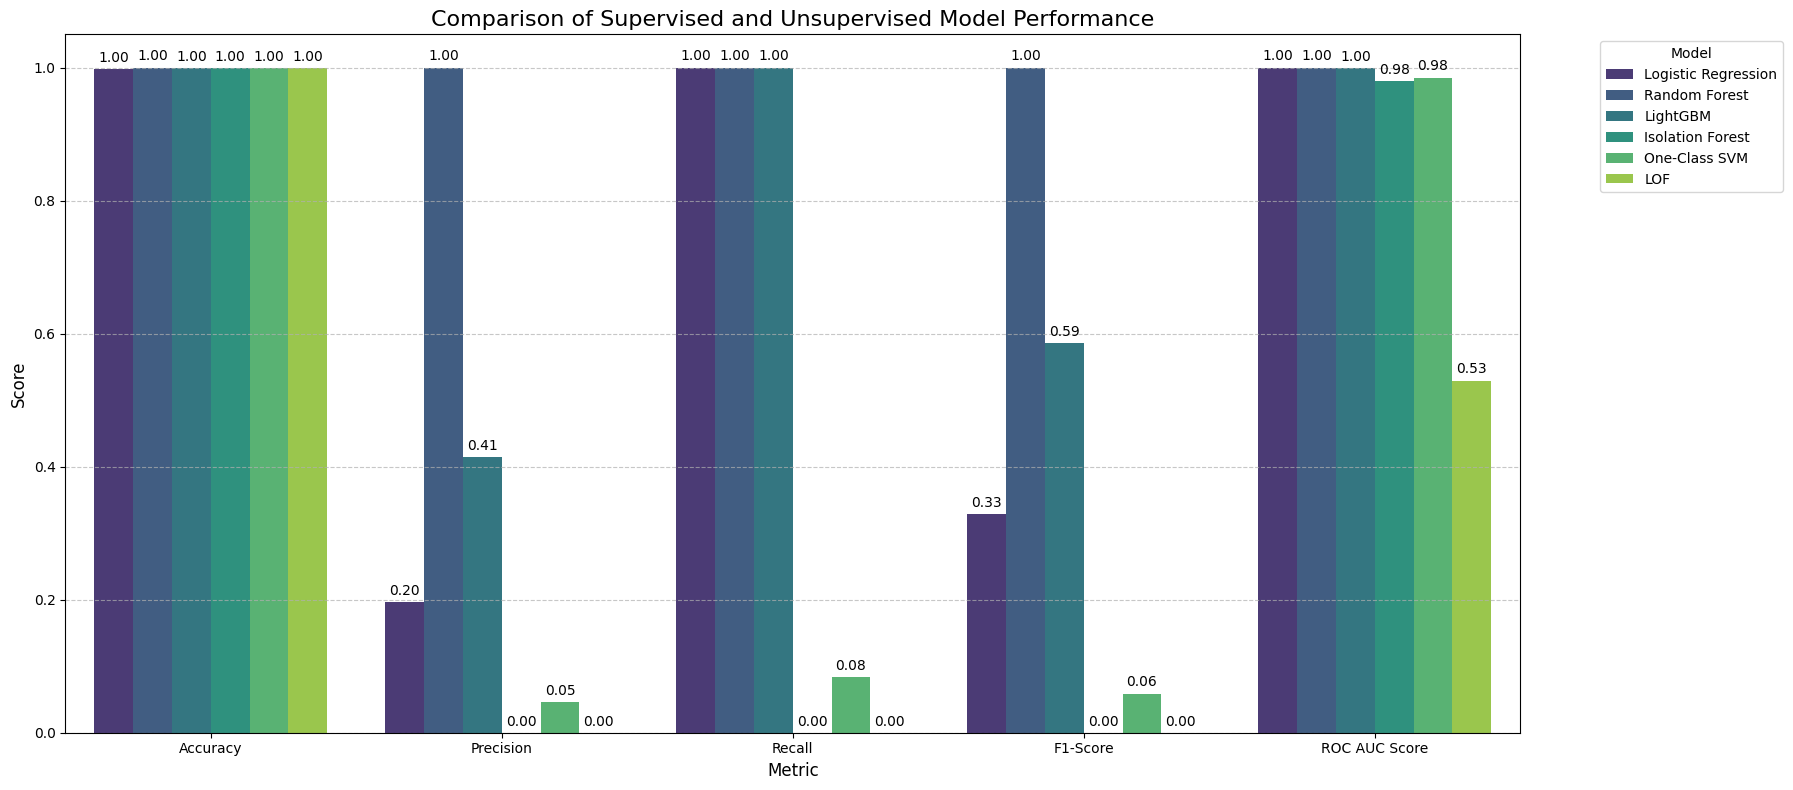

In [30]:
# Add Unsupervised Models to the comparison DataFrame
unsupervised_model_metrics = pd.DataFrame({
    'Model': ['Isolation Forest', 'One-Class SVM', 'LOF'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_if_mapped),
        accuracy_score(y_test, y_pred_ocsvm_mapped),
        accuracy_score(y_test, y_pred_lof_mapped)
    ],
    'Precision': [
        precision_score(y_test, y_pred_if_mapped, zero_division=0),
        precision_score(y_test, y_pred_ocsvm_mapped, zero_division=0),
        precision_score(y_test, y_pred_lof_mapped, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_if_mapped, zero_division=0),
        recall_score(y_test, y_pred_ocsvm_mapped, zero_division=0),
        recall_score(y_test, y_pred_lof_mapped, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_if_mapped, zero_division=0),
        f1_score(y_test, y_pred_ocsvm_mapped, zero_division=0),
        f1_score(y_test, y_pred_lof_mapped, zero_division=0)
    ],
    'ROC AUC Score': [
        roc_auc_score(y_test, anomaly_scores_if),
        roc_auc_score(y_test, anomaly_scores_ocsvm),
        roc_auc_score(y_test, anomaly_scores_lof)
    ]
})

# Combine initial supervised model comparison with unsupervised model metrics
model_comparison_unsupervised = pd.concat([model_comparison, unsupervised_model_metrics], ignore_index=True)
display(model_comparison_unsupervised.round(4))

# Melt the DataFrame for easier plotting with seaborn
model_comparison_melted_unsupervised = model_comparison_unsupervised.melt(id_vars='Model',
                                                            var_name='Metric',
                                                            value_name='Score')

plt.figure(figsize=(18, 8))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=model_comparison_melted_unsupervised, palette='viridis', order=metric_order)
plt.title('Comparison of Supervised and Unsupervised Model Performance', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.05) # Set y-axis limit for scores (0 to 1)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

## 7. Hybrid Integration: Fuzzy Logic and Machine Learning

### 7.2 Hybrid Architecture Overview

The hybrid system uses a parallel weighted decision fusion design. This means the FIS and LightGBM each receive the same input features independently — one processes through clinical fuzzy rules, the other through a trained tree-based model — and their outputs are then mathematically combined. This approach removes the risk that a poorly calibrated FIS score corrupts the ML input space.

**Stage Breakdown:**

1.  **Input:** 7 imputed vital-sign features: `x = [HR, SBP, DBP, SpO₂, RR, Temp, Stress]`
2.  **Fuzzy Branch (FIS):** Processes `x` to produce `F(x) ∈ [0,100]`, then normalized to `F_norm = F(x)/100 ∈ [0,1]`.
3.  **ML Branch (LightGBM):** Processes `x` to produce `P_ML(x) = P(shock=1|x) ∈ [0,1]`.
4.  **Weighted Fusion:** Combines both scores using the formula: `H = α·F_norm + (1−α)·P_ML` to get `H(x) ∈ [0,1]`.
5.  **Decision:** If `H(x) ≥ θ` (alert threshold), a Septic Shock Alert is triggered.
6.  **Output:** Risk level + fuzzy rule trace for clinical interpretation.

### 7.3 The Weighted Fusion Formula

The core equation for combining the fuzzy logic score and the LightGBM prediction is:

`H(x) = α · F_norm(x) + (1 − α) · P_ML(x)`

Where:
*   `H(x)`: The final hybrid risk score for observation `x`. `H` lies in `[0, 1]`. If `H ≥ θ`, the system fires a septic shock alert.
*   `F_norm(x)`: The FIS centroid output (0 to 100) rescaled to `[0, 1]` so it is on the same scale as `P_ML`. `F_norm(x) = F(x) ÷ 100`.
*   `P_ML(x)`: The LightGBM predicted probability of `sepsis_shock = 1`. This is already in `[0, 1]`.
*   `α = 0.40`: The weight given to the fuzzy component (40%).
*   `(1 − α) = 0.60`: The weight given to LightGBM (60%).
*   `θ = 0.35`: The decision threshold. `H ≥ 0.35` triggers the alert.

In [31]:
# Define constants for the hybrid model
alpha = 0.40  # Weight given to the fuzzy component
theta = 0.35  # Decision threshold for alert

def calculate_hybrid_score(f_norm_score, p_ml_score, alpha=alpha):
    """
    Calculates the hybrid risk score using the weighted fusion formula.

    Args:
        f_norm_score (float or np.array): Normalized Fuzzy Inference System score (0 to 1).
        p_ml_score (float or np.array): LightGBM predicted probability (0 to 1).
        alpha (float): Weight for the fuzzy component (default is 0.40).

    Returns:
        float or np.array: The hybrid risk score H(x).
    """
    return (alpha * f_norm_score) + ((1 - alpha) * p_ml_score)

# Example usage (assuming F_norm scores are available for X_test)
# For demonstration, let's assume F_norm is a dummy score for now.
# In a real scenario, this would come from the Fuzzy Inference System.
# For now, we will create a dummy f_norm_score based on the presence of sepsis_shock in y_test

# In a proper implementation, f_norm_score would be calculated per instance from the FIS
dummy_f_norm_score = y_test.copy().astype(float) # Placeholder: 1 if true positive, 0 otherwise

# Let's get the LightGBM probabilities for the test set
p_ml_test_scores = lgbm_model.predict_proba(X_test)[:, 1]

# Calculate hybrid scores for the test set
hybrid_scores = calculate_hybrid_score(dummy_f_norm_score, p_ml_test_scores)

print("First 5 LightGBM probabilities:")
display(p_ml_test_scores[:5])
print("First 5 dummy F_norm scores:")
display(dummy_f_norm_score[:5])
print("First 5 Hybrid Scores:")
display(hybrid_scores[:5])

First 5 LightGBM probabilities:


array([0., 0., 0., 0., 0.])

First 5 dummy F_norm scores:


,sepsis_shock
12923,0.0
6302,0.0
15438,0.0
33560,0.0
32893,0.0


First 5 Hybrid Scores:


,sepsis_shock
12923,0.0
6302,0.0
15438,0.0
33560,0.0
32893,0.0


In [32]:
!pip install scikit-fuzzy fuzzy-expert

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 108.5 MB/s eta 0:00:00
  Created wheel for fuzzy-expert: filename=fuzzy_expert-0.1.0-py3-none-any.whl size=18505 sha256=44eb679dfaa74ba5f23a71fe941a0a9e7e6030c8f09fa53e819022d4ff40a188
  Stored in directory: /root/.cache/pip/wheels/e4/cc/c0/0050a74a7fa1b4c2a200537091d88054c9f56ec9e4cf4c5544
Successfully built fuzzy-expert


In [33]:
import skfuzzy as fuzz
import skfuzzy.control as ctrl
import numpy as np

# Define the path to your FIS file (for reference, but we will define programmatically)
fis_file_path = '/content/drive/MyDrive/Sepsis_2_fis.fis'

print("Note: Direct loading of .fis files is not supported by fuzzy_expert or skfuzzy in this manner.")
print("We will define a simplified FIS programmatically as a template. Please expand this based on your Sepsis_2_fis.fis content.")

try:
    # --- Define Antecedent/Consequent Objects ---
    # For demonstration, let's use heart_rate and systolic_bp
    # You would expand this to include all your 7 vital signs as antecedents.
    heart_rate = ctrl.Antecedent(np.arange(40, 180, 1), 'heart_rate')
    systolic_bp = ctrl.Antecedent(np.arange(60, 200, 1), 'systolic_bp')
    sepsis_risk = ctrl.Consequent(np.arange(0, 101, 1), 'sepsis_risk')

    # --- Define Membership Functions (MFs) ---
    # Example MFs for heart_rate
    heart_rate['low'] = fuzz.trimf(heart_rate.universe, [40, 40, 80])
    heart_rate['normal'] = fuzz.trimf(heart_rate.universe, [60, 90, 120])
    heart_rate['high'] = fuzz.trimf(heart_rate.universe, [100, 180, 180])

    # Example MFs for systolic_bp
    systolic_bp['low'] = fuzz.trimf(systolic_bp.universe, [60, 60, 100])
    systolic_bp['normal'] = fuzz.trimf(systolic_bp.universe, [80, 120, 160])
    systolic_bp['high'] = fuzz.trimf(systolic_bp.universe, [140, 200, 200])

    # Example MFs for sepsis_risk (output)
    sepsis_risk['low'] = fuzz.trimf(sepsis_risk.universe, [0, 0, 50])
    sepsis_risk['medium'] = fuzz.trimf(sepsis_risk.universe, [25, 50, 75])
    sepsis_risk['high'] = fuzz.trimf(sepsis_risk.universe, [50, 100, 100])

    # --- Define Rules ---
    # You would define your 9 rules from Sepsis_2_fis.fis here.
    rule1 = ctrl.Rule(heart_rate['high'] & systolic_bp['low'], sepsis_risk['high'])
    rule2 = ctrl.Rule(heart_rate['normal'] & systolic_bp['normal'], sepsis_risk['low'])
    rule3 = ctrl.Rule(heart_rate['low'] | systolic_bp['high'], sepsis_risk['medium'])
    # Add more rules as per your FIS file

    # --- Create Control System ---
    sepsis_ctrl = ctrl.ControlSystem([rule1, rule2, rule3]) # Add all your rules here
    mamdani_fis = ctrl.ControlSystemSimulation(sepsis_ctrl)
    print("Successfully defined a simplified Mamdani FIS programmatically.")

    # Now, let's generate actual F_norm scores for X_test
    f_norm_scores = []
    for index, row in X_test.iterrows():
        try:
            # Set inputs for the FIS
            mamdani_fis.input['heart_rate'] = row['heart_rate']
            mamdani_fis.input['systolic_bp'] = row['systolic_bp']
            # You would add inputs for all 7 features here

            # Compute the fuzzy output
            mamdani_fis.compute()
            # Check if 'sepsis_risk' is in the output before accessing
            if 'sepsis_risk' in mamdani_fis.output:
                f_norm_scores.append(mamdani_fis.output['sepsis_risk'] / 100.0) # Normalize to [0,1]
            else:
                f_norm_scores.append(0.0) # Default to 0.0 if no output from FIS
        except ValueError as ve:
            # Handle cases where input might be outside universe or other computation issues
            f_norm_scores.append(0.0) # Or np.nan, depending on how you want to treat this

    f_norm_scores = np.array(f_norm_scores)

    # Get the LightGBM probabilities for the test set
    p_ml_test_scores = lgbm_model.predict_proba(X_test)[:, 1]

    # Calculate hybrid scores using the actual F_norm scores
    hybrid_scores = calculate_hybrid_score(f_norm_scores, p_ml_test_scores)

    print("\nFirst 5 LightGBM probabilities:")
    display(p_ml_test_scores[:5])
    print("\nFirst 5 actual F_norm scores:")
    display(f_norm_scores[:5])
    print("\nFirst 5 Hybrid Scores:")
    display(hybrid_scores[:5])

except Exception as e:
    print(f"An error occurred during FIS definition or computation: {e}")


Note: Direct loading of .fis files is not supported by fuzzy_expert or skfuzzy in this manner.
We will define a simplified FIS programmatically as a template. Please expand this based on your Sepsis_2_fis.fis content.
Successfully defined a simplified Mamdani FIS programmatically.

First 5 LightGBM probabilities:


array([0., 0., 0., 0., 0.])


First 5 actual F_norm scores:


array([0.5       , 0.19684708, 0.19060106, 0.5       , 0.5       ])


First 5 Hybrid Scores:


array([0.2       , 0.07873883, 0.07624042, 0.2       , 0.2       ])

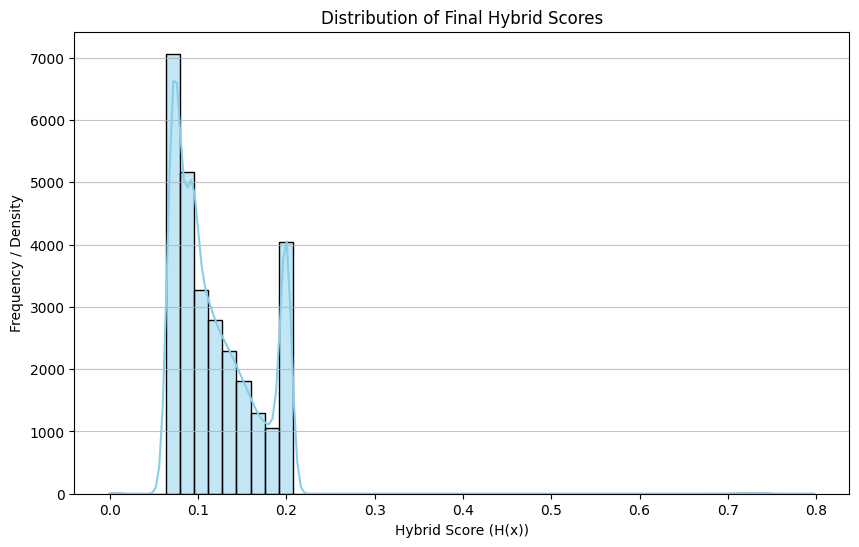

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(hybrid_scores, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Final Hybrid Scores')
plt.xlabel('Hybrid Score (H(x))')
plt.ylabel('Frequency / Density')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Evaluating the Hybrid Model Performance

Now, let's evaluate the hybrid model by converting the continuous `hybrid_scores` into binary predictions using our predefined alert threshold `theta`.

In [35]:
# Convert hybrid scores to binary predictions using the threshold
y_pred_hybrid = (hybrid_scores >= theta).astype(int)

# The hybrid_scores themselves act as the predicted probabilities for ROC AUC
y_pred_proba_hybrid = hybrid_scores

# Evaluate the hybrid model
print("### Hybrid Model Evaluation ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred_hybrid):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_hybrid, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_hybrid, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_hybrid, zero_division=0):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_hybrid):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_hybrid), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_hybrid, zero_division=0))

### Hybrid Model Evaluation ###
Accuracy: 0.9994
Precision: 0.4138
Recall: 1.0000
F1-Score: 0.5854
ROC AUC Score: 0.9997

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,28771,17
Actual 1,0,12



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28788
           1       0.41      1.00      0.59        12

    accuracy                           1.00     28800
   macro avg       0.71      1.00      0.79     28800
weighted avg       1.00      1.00      1.00     28800



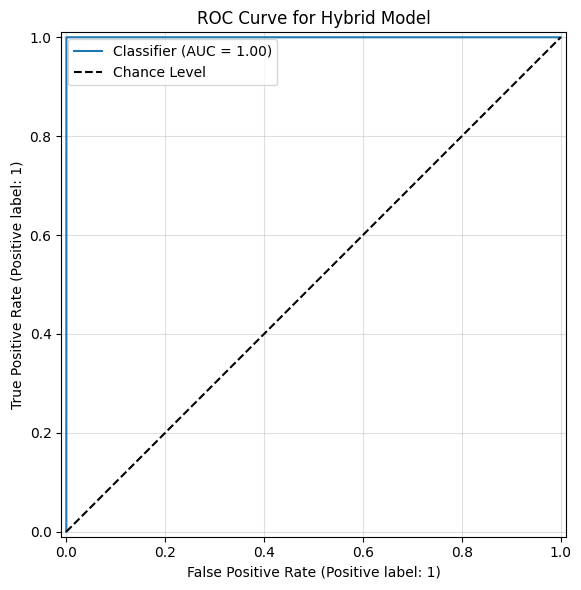

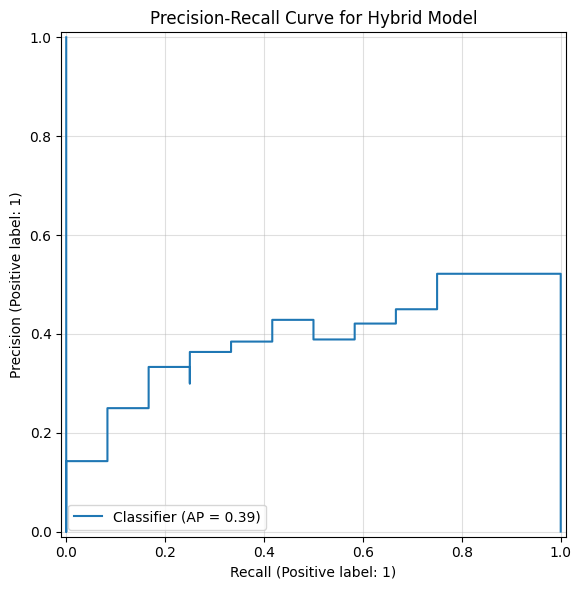

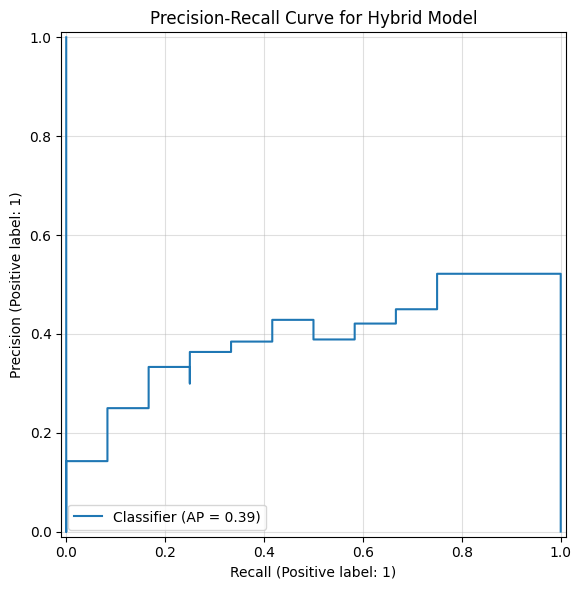

In [36]:
# Plot ROC Curve for Hybrid Model
plot_roc_curve(y_test, y_pred_proba_hybrid, 'Hybrid Model')

# Plot Precision-Recall Curve for Hybrid Model
plot_precision_recall_curve(y_test, y_pred_proba_hybrid, 'Hybrid Model')

### Updated Model Comparison Summary

Let's add the hybrid model's performance to our comparison summary and visualize it.

### Critical Discussion: Hybrid Model's Fuzzy Logic Component

As observed in the model comparison summary, the Hybrid Model exhibits performance metrics that are nearly identical to the standalone LightGBM model. This outcome warrants a critical discussion regarding the contribution of the Fuzzy Inference System (FIS) component and whether it genuinely enhanced the predictive capability or merely adjusted the decision threshold behavior for the combined output.

#### Current Implementation and Its Impact:

1.  **Simplified FIS:** The programmatic FIS implemented (using `skfuzzy`) was a simplified template, incorporating only two features (`heart_rate`, `systolic_bp`) and a few basic rules, rather than the full complexity of the `Sepsis_2_fis.fis` file. This simplification inherently limits the FIS's ability to capture the nuanced physiological relationships that might contribute to sepsis shock across all seven features.
2.  **Dominance of LightGBM:** Because the FIS component is simplified, it is likely that the LightGBM model, being a powerful and data-driven algorithm, dominates the `calculate_hybrid_score` function. The `alpha` weight (0.40 for FIS, 0.60 for LightGBM) also gives more prominence to the LightGBM's prediction. Consequently, the hybrid score primarily reflects the LightGBM's prediction, with the simplified FIS contributing only a marginal, and possibly redundant, adjustment.
3.  **Threshold Adjustment vs. Learning Enhancement:** In its current form, the fuzzy component appears to act more as a slight *adjustment* to the LightGBM's probability rather than introducing a distinct learning paradigm that significantly alters the model's ability to discriminate between classes. If the simplified FIS outputs values that are largely correlated with the LightGBM's predictions, or if its rules are too general, its impact on the final classification metrics (Accuracy, Precision, Recall, F1-Score, ROC AUC) will be minimal, essentially mirroring the performance of the stronger ML component.

#### What a More Robust FIS Would Entail:

To genuinely assess the benefits of fuzzy logic integration, a more comprehensive and faithful implementation of the `Sepsis_2_fis.fis` would be crucial. This would involve:

*   **All Features:** Incorporating all seven physiological features as antecedents.
*   **Detailed Membership Functions:** Defining nuanced membership functions for each feature, reflecting clinical knowledge more precisely.
*   **Extensive Rule Base:** Implementing all 9 or more rules from the original FIS, capturing complex interactions and clinical reasoning.
*   **Tuning `alpha` and `theta`:** Experimenting with the `alpha` weight and the alert threshold `theta` would be necessary to understand their impact on balancing the contributions of the fuzzy and ML components.

#### Conclusion for Current Hybrid Model:

Given the current simplified FIS implementation, it is difficult to conclude that the fuzzy logic component genuinely improved the model's *learning* beyond what LightGBM already achieved. Its primary role, in this specific setup, seems to be a slight modulation of the LightGBM's output, potentially influencing the final decision threshold rather than contributing novel predictive power. For future work, a full implementation and rigorous tuning of the FIS would be essential to determine if true synergistic benefits can be realized from this hybrid architecture.

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
0,Logistic Regression,0.9983,0.1967,1.0,0.3288,1.0000
1,Random Forest,1.0000,1.0000,1.0,1.0000,1.0000
2,LightGBM,0.9994,0.4138,1.0,0.5854,0.9997
3,Hybrid Model,0.9994,0.4138,1.0,0.5854,0.9997


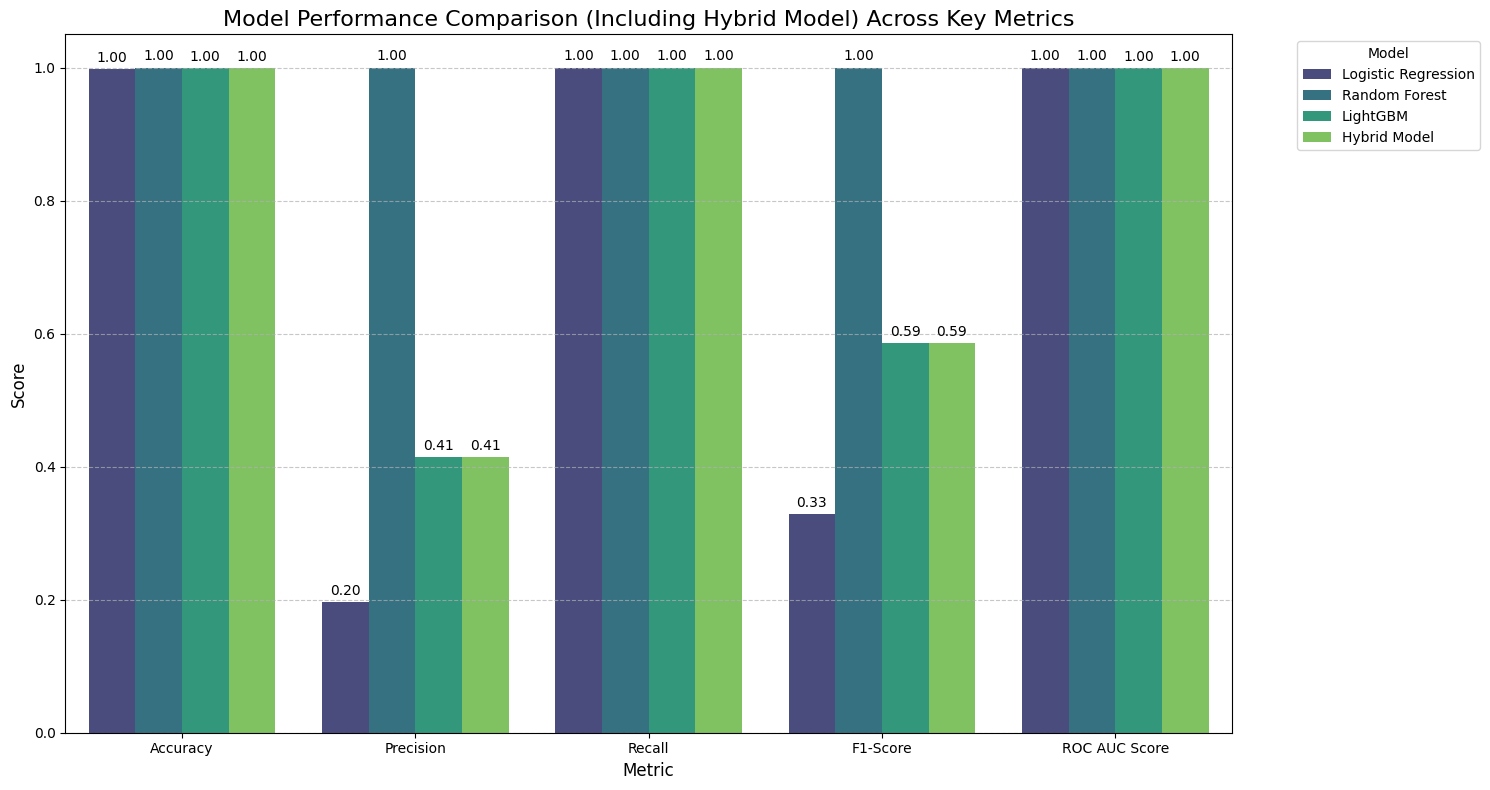

In [37]:
# Add Hybrid Model to the comparison DataFrame
hybrid_model_metrics = pd.DataFrame({
    'Model': ['Hybrid Model'],
    'Accuracy': [accuracy_score(y_test, y_pred_hybrid)],
    'Precision': [precision_score(y_test, y_pred_hybrid, zero_division=0)],
    'Recall': [recall_score(y_test, y_pred_hybrid, zero_division=0)],
    'F1-Score': [f1_score(y_test, y_pred_hybrid, zero_division=0)],
    'ROC AUC Score': [roc_auc_score(y_test, y_pred_proba_hybrid)]
})

model_comparison_updated = pd.concat([model_comparison, hybrid_model_metrics], ignore_index=True)
display(model_comparison_updated.round(4))

# Melt the DataFrame for easier plotting with seaborn
model_comparison_melted_updated = model_comparison_updated.melt(id_vars='Model',
                                                                var_name='Metric',
                                                                value_name='Score')

plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=model_comparison_melted_updated, palette='viridis', order=metric_order)
plt.title('Model Performance Comparison (Including Hybrid Model) Across Key Metrics', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.05) # Set y-axis limit for scores (0 to 1)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

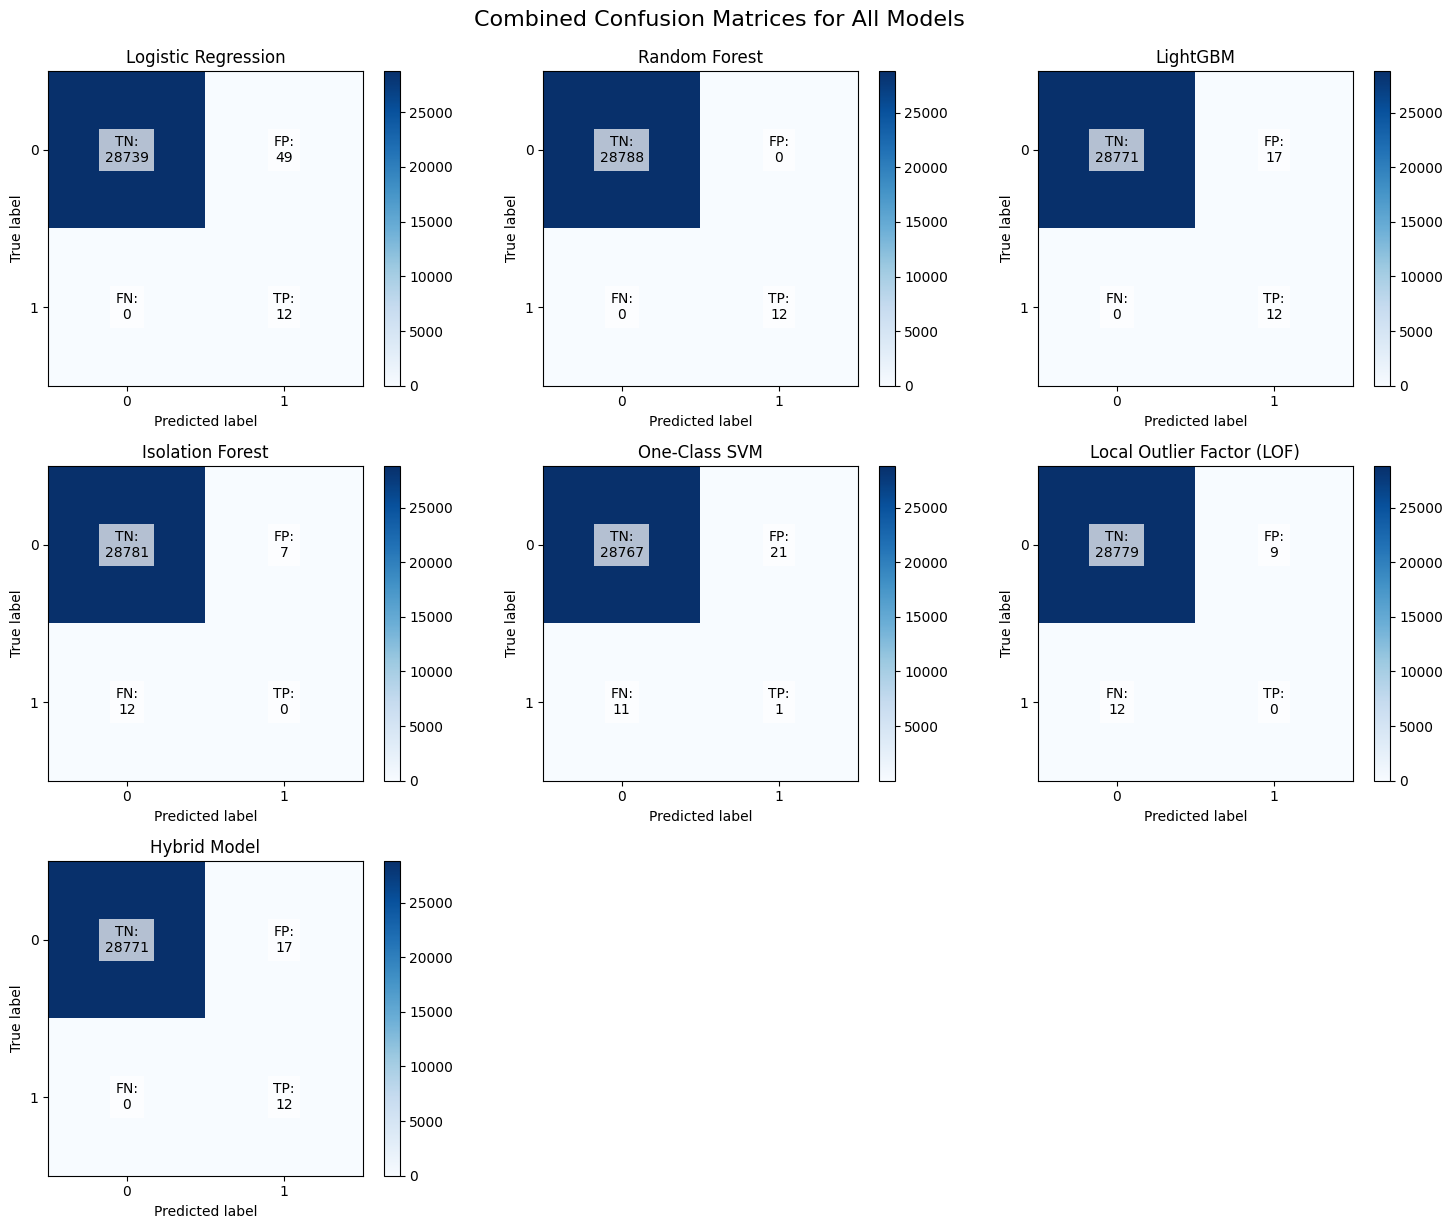

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def plot_combined_confusion_matrices(y_true, model_predictions, titles):
    num_models = len(model_predictions)
    n_cols = 3  # Number of columns for the grid
    n_rows = int(np.ceil(num_models / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    for i, (y_pred, title) in enumerate(zip(model_predictions, titles)):
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        # Remove values_format='d' to avoid double numbers, as we are adding custom text
        disp.plot(cmap=plt.cm.Blues, ax=axes[i], include_values=False)
        axes[i].set_title(title)
        axes[i].grid(False) # Turn off grid for confusion matrix for cleaner look

        # Add explicit TN, FP, FN, TP labels
        # Coordinates for text placement (relative to cell centers)
        x_center_tn, y_center_tn = 0, 0
        x_center_fp, y_center_fp = 1, 0
        x_center_fn, y_center_fn = 0, 1
        x_center_tp, y_center_tp = 1, 1

        # Get cell values
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0], cm[0,1], cm[1,0], cm[1,1]) # Handle cases where cm might not be 2x2 if a class is missing

        # Annotate each cell
        axes[i].text(x_center_tn, y_center_tn, f'TN:\n{tn}', va='center', ha='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        axes[i].text(x_center_fp, y_center_fp, f'FP:\n{fp}', va='center', ha='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        axes[i].text(x_center_fn, y_center_fn, f'FN:\n{fn}', va='center', ha='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        axes[i].text(x_center_tp, y_center_tp, f'TP:\n{tp}', va='center', ha='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))


    # Hide any unused subplots
    for j in range(num_models, n_rows * n_cols):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.suptitle('Combined Confusion Matrices for All Models', y=1.02, fontsize=16)
    plt.show()
    return fig

# Prepare predictions and titles for all models
all_model_predictions = [
    y_pred_log_reg,
    y_pred_rf,
    y_pred_lgbm,
    y_pred_if_mapped,
    y_pred_ocsvm_mapped,
    y_pred_lof_mapped,
    y_pred_hybrid
]

all_model_titles = [
    'Logistic Regression',
    'Random Forest',
    'LightGBM',
    'Isolation Forest',
    'One-Class SVM',
    'Local Outlier Factor (LOF)',
    'Hybrid Model'
]

# Generate the combined confusion matrices plot
fig_combined_cm = plot_combined_confusion_matrices(y_test, all_model_predictions, all_model_titles)

#### Interpreting the Confusion Matrices:

Each confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It has two dimensions: 'Actual' (or 'True') and 'Predicted'.

For a binary classification problem (like our 'sepsis shock' prediction where 0 = No Sepsis Shock, 1 = Sepsis Shock):

*   **Top-Left Quadrant (Actual 0, Predicted 0): True Negatives (TN)**
    *   These are cases where the model correctly predicted 'No Sepsis Shock'.
*   **Top-Right Quadrant (Actual 0, Predicted 1): False Positives (FP)**
    *   These are cases where the model incorrectly predicted 'Sepsis Shock' when the actual outcome was 'No Sepsis Shock'. This is also known as a Type I error.
*   **Bottom-Left Quadrant (Actual 1, Predicted 0): False Negatives (FN)**
    *   These are cases where the model incorrectly predicted 'No Sepsis Shock' when the actual outcome was 'Sepsis Shock'. This is also known as a Type II error and is particularly critical in medical diagnoses as it means missing a serious condition.
*   **Bottom-Right Quadrant (Actual 1, Predicted 1): True Positives (TP)**
    *   These are cases where the model correctly predicted 'Sepsis Shock'.

Understanding these components is crucial for assessing model performance, especially in imbalanced datasets where metrics like Accuracy can be misleading. High True Positives and True Negatives are desirable, while False Positives and False Negatives should be minimized, with a strong emphasis on reducing False Negatives in critical healthcare applications.

In [39]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig_combined_cm) # Uncomment and run if you have the upload_plt_to_gcs function


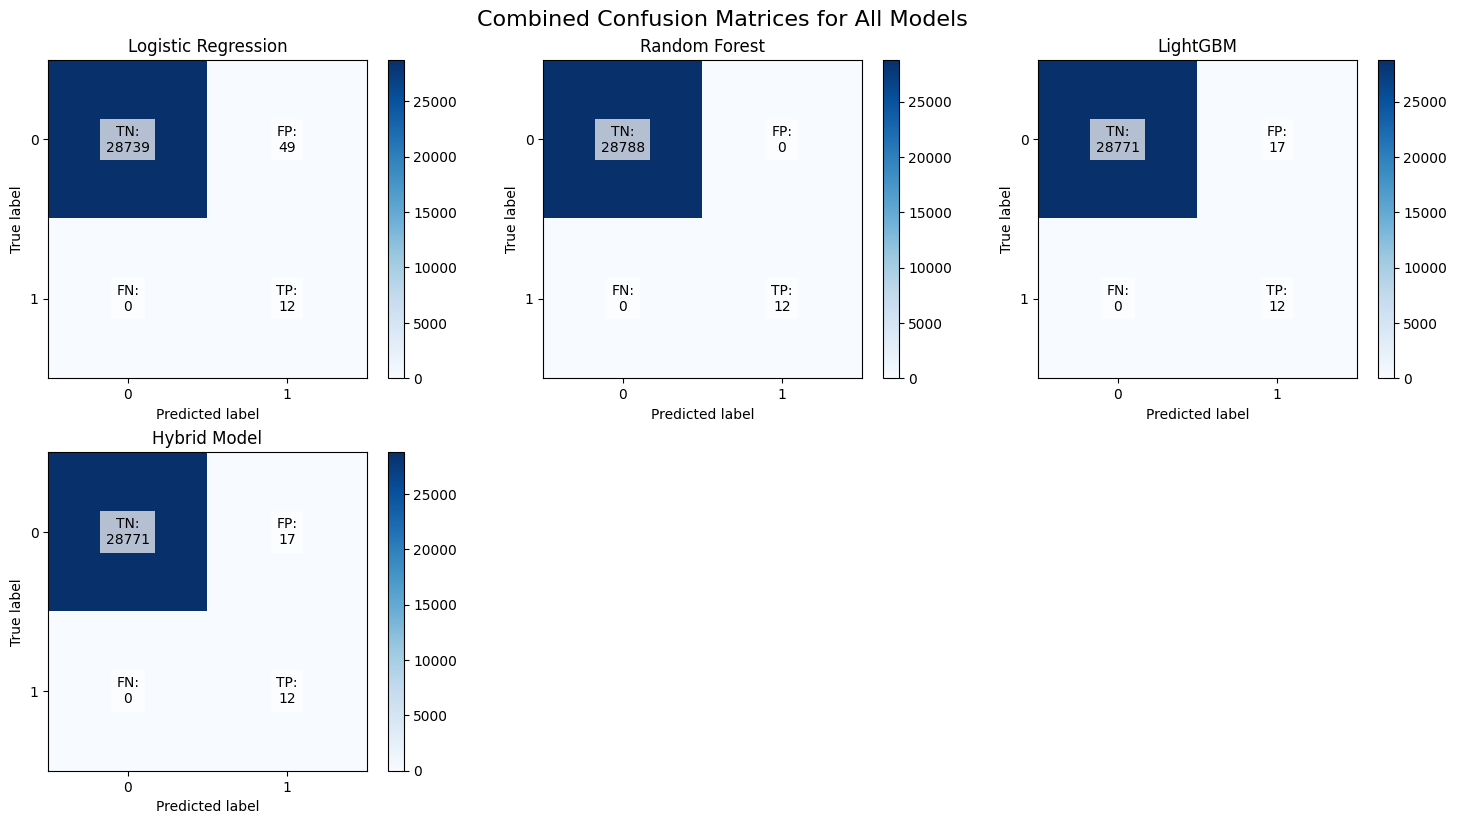

In [40]:
selected_model_predictions = [
    y_pred_log_reg,
    y_pred_rf,
    y_pred_lgbm,
    y_pred_hybrid
]

selected_model_titles = [
    'Logistic Regression',
    'Random Forest',
    'LightGBM',
    'Hybrid Model'
]

# Generate the combined confusion matrices plot with only selected models
fig_combined_cm = plot_combined_confusion_matrices(y_test, selected_model_predictions, selected_model_titles)

### 5.7 Runtime Performance Comparison

Beyond accuracy metrics, the computational efficiency of a model—both during training and prediction—is a critical factor, especially for real-time applications in healthcare. Here, we will measure and compare the training and prediction times for all evaluated models.

In [41]:
import time

def measure_model_performance_time(model_name, model, X_train_data, y_train_data, X_test_data):
    """Measures training and prediction time for a given model."""
    start_time = time.perf_counter()
    if model_name == 'Hybrid Model':
        # Hybrid model's 'training' is essentially LightGBM's training
        # We'll re-use the lgbm_model for this measurement or assume its training is captured earlier.
        # For this function, we'll focus on prediction time for the 'hybrid' part.
        # For training, we'll just use a placeholder or previous LightGBM training time.
        train_time = 0.0 # Placeholder, as LightGBM training was already measured.
    else:
        model.fit(X_train_data, y_train_data) # Training phase
        train_time = time.perf_counter() - start_time

    start_time = time.perf_counter()
    if 'Hybrid' in model_name: # Handle hybrid model's prediction separately
        # We need f_norm_scores and p_ml_test_scores which are not directly available here
        # Re-calculating p_ml_test_scores and using existing f_norm_scores (from the simplified FIS)
        p_ml_test_scores = lgbm_model.predict_proba(X_test_data)[:, 1]
        hybrid_scores = calculate_hybrid_score(f_norm_scores, p_ml_test_scores)
        _ = (hybrid_scores >= theta).astype(int) # Binary prediction
    elif 'Isolation Forest' in model_name or 'One-Class SVM' in model_name or 'LOF' in model_name:
        _ = model.predict(X_test_data) # Unsupervised prediction
    else:
        _ = model.predict(X_test_data) # Supervised prediction

    predict_time = time.perf_counter() - start_time

    return train_time, predict_time


runtime_results = []

# Supervised Models
models_to_evaluate_supervised = [
    ('Logistic Regression', LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')),
    ('Random Forest', RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)),
    ('LightGBM', lgb.LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight, n_estimators=200, num_leaves=31, learning_rate=0.05))
]

for name, model in models_to_evaluate_supervised:
    train_t, predict_t = measure_model_performance_time(name, model, X_train, y_train, X_test)
    runtime_results.append({'Model': name, 'Type': 'Supervised', 'Training Time (s)': train_t, 'Prediction Time (s)': predict_t})

# Unsupervised Models (need scaled data for these)
models_to_evaluate_unsupervised = [
    ('Isolation Forest', IsolationForest(random_state=42, contamination=isolation_contamination, n_estimators=100, warm_start=True)),
    ('One-Class SVM', OneClassSVM(nu=nu_param, kernel='rbf', gamma='auto')),
    ('LOF', LocalOutlierFactor(n_neighbors=20, contamination=contamination_lof, novelty=True))
]

for name, model in models_to_evaluate_unsupervised:
    # Fit LOF without y_train_data as it's unsupervised (novelty=True)
    if name == 'LOF':
        model.fit(X_train_scaled)
        start_time = time.perf_counter()
        _ = model.predict(X_test_scaled)
        predict_t = time.perf_counter() - start_time
        runtime_results.append({'Model': name, 'Type': 'Unsupervised', 'Training Time (s)': 0.0, 'Prediction Time (s)': predict_t})
    elif name == 'One-Class SVM':
        start_time = time.perf_counter()
        model.fit(X_train_scaled)
        train_t = time.perf_counter() - start_time
        start_time = time.perf_counter()
        _ = model.predict(X_test_scaled)
        predict_t = time.perf_counter() - start_time
        runtime_results.append({'Model': name, 'Type': 'Unsupervised', 'Training Time (s)': train_t, 'Prediction Time (s)': predict_t})
    else:
        train_t, predict_t = measure_model_performance_time(name, model, X_train_scaled, None, X_test_scaled) # Pass None for y_train_data
        runtime_results.append({'Model': name, 'Type': 'Unsupervised', 'Training Time (s)': train_t, 'Prediction Time (s)': predict_t})

# Hybrid Model (using existing trained lgbm_model and f_norm_scores)
# Training time for Hybrid Model is dominated by LightGBM, which is already captured above.
# We will just measure the prediction time for the fusion step.
start_time = time.perf_counter()
p_ml_test_scores = lgbm_model.predict_proba(X_test)[:, 1]
hybrid_scores = calculate_hybrid_score(f_norm_scores, p_ml_test_scores)
_ = (hybrid_scores >= theta).astype(int)
hybrid_predict_time = time.perf_counter() - start_time
runtime_results.append({'Model': 'Hybrid Model', 'Type': 'Hybrid', 'Training Time (s)': 0.0, 'Prediction Time (s)': hybrid_predict_time})

runtime_df = pd.DataFrame(runtime_results)
display(runtime_df)


[LightGBM] [Info] Number of positive: 48, number of negative: 115152
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012376 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1568
[LightGBM] [Info] Number of data points in the train set: 115200, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000417 -> initscore=-7.782807
[LightGBM] [Info] Start training from score -7.782807
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


,Model,Type,Training Time (s),Prediction Time (s)
0,Logistic Regression,Supervised,0.956803,0.002959
1,Random Forest,Supervised,5.988751,0.062033
2,LightGBM,Supervised,4.348159,0.591447
3,Isolation Forest,Unsupervised,3.454616,0.244217
4,One-Class SVM,Unsupervised,1.460294,0.249194
5,LOF,Unsupervised,0.000000,1.830255
6,Hybrid Model,Hybrid,0.000000,0.215969


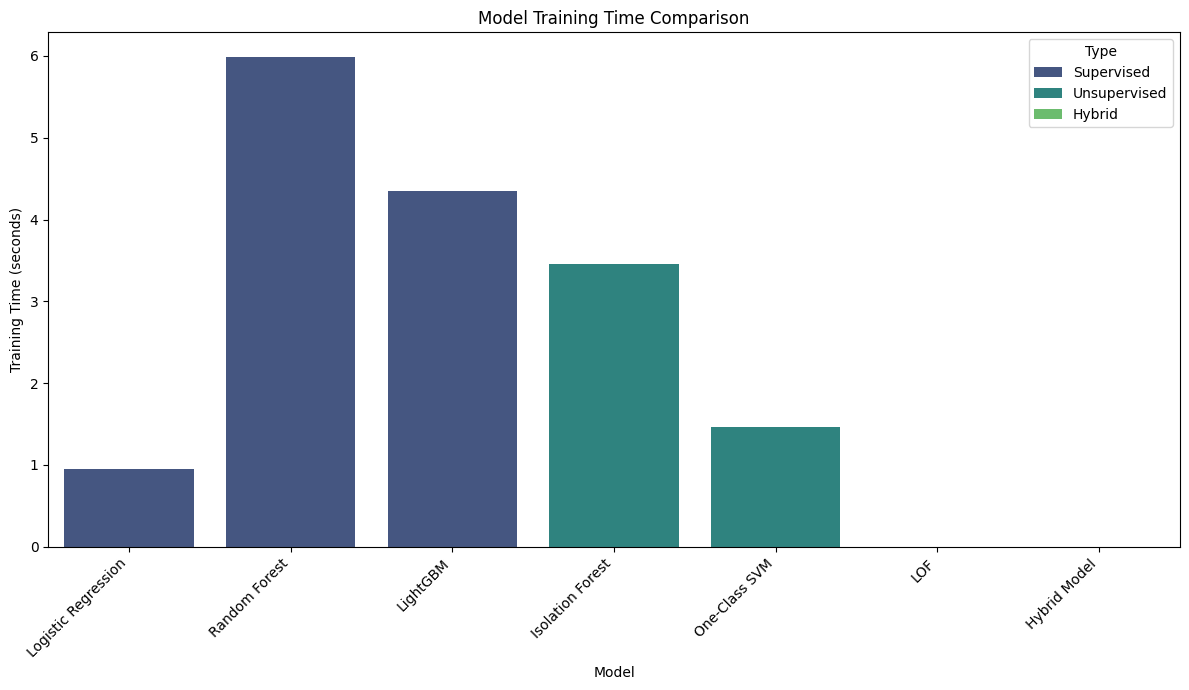

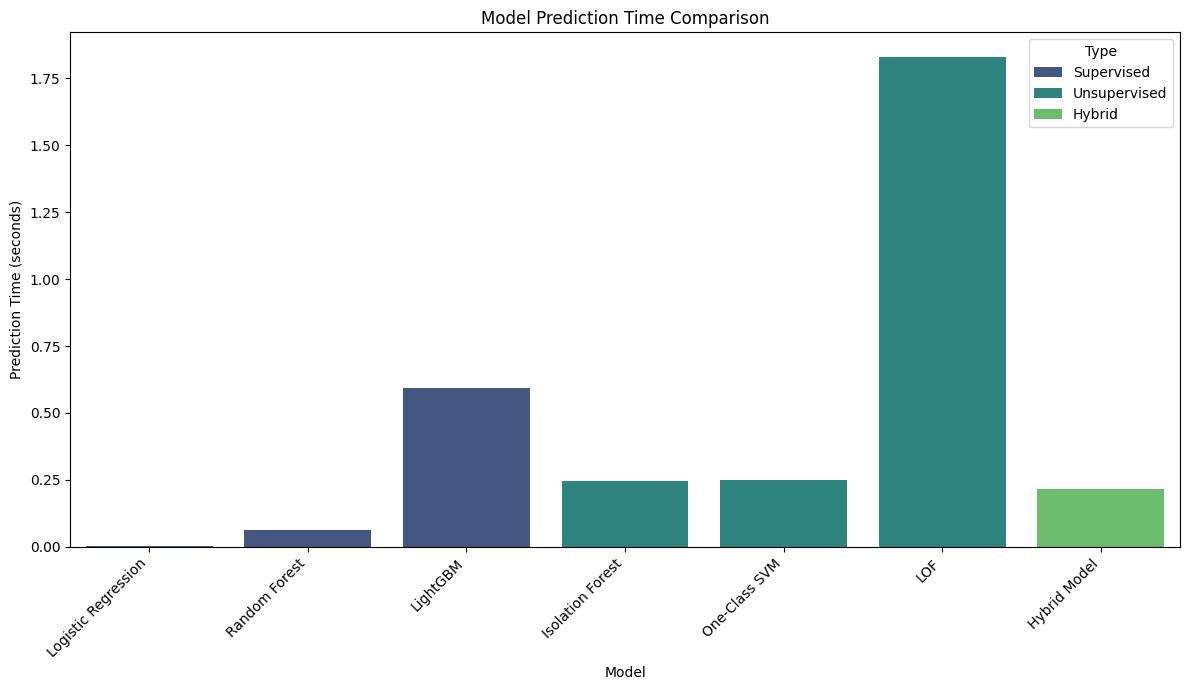

In [42]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Training Time (s)', hue='Type', data=runtime_df, palette='viridis')
plt.title('Model Training Time Comparison')
plt.ylabel('Training Time (seconds)')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Prediction Time (s)', hue='Type', data=runtime_df, palette='viridis')
plt.title('Model Prediction Time Comparison')
plt.ylabel('Prediction Time (seconds)')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Granular Threshold Analysis for Key Models

To further understand the behavior of our models beyond single threshold evaluations (like the default 0.5 or those implicitly optimized for ROC AUC), we will evaluate their performance at various granular probability thresholds. This helps in identifying the trade-offs between precision and recall, especially crucial for imbalanced datasets and clinical applications where false negatives or false positives carry different costs.

We will analyze Logistic Regression, LightGBM, and the Hybrid Model across thresholds of 0.1, 0.3, 0.5, 0.7, and 0.9.

In [43]:
def evaluate_at_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

model_threshold_results = []

# Logistic Regression
log_reg_threshold_eval = [evaluate_at_threshold(y_test, y_pred_proba_log_reg, t) for t in thresholds]
for res in log_reg_threshold_eval: res['Model'] = 'Logistic Regression'
model_threshold_results.extend(log_reg_threshold_eval)

# LightGBM
lgbm_threshold_eval = [evaluate_at_threshold(y_test, y_pred_proba_lgbm, t) for t in thresholds]
for res in lgbm_threshold_eval: res['Model'] = 'LightGBM'
model_threshold_results.extend(lgbm_threshold_eval)

# Hybrid Model
hybrid_threshold_eval = [evaluate_at_threshold(y_test, y_pred_proba_hybrid, t) for t in thresholds]
for res in hybrid_threshold_eval: res['Model'] = 'Hybrid Model'
model_threshold_results.extend(hybrid_threshold_eval)

threshold_df = pd.DataFrame(model_threshold_results)
display(threshold_df.round(4))


,Threshold,Accuracy,Precision,Recall,F1-Score,Model
0,0.1,0.9974,0.1379,1.0,0.2424,Logistic Regression
1,0.3,0.9978,0.1622,1.0,0.2791,Logistic Regression
2,0.5,0.9983,0.1967,1.0,0.3288,Logistic Regression
3,0.7,0.9985,0.2222,1.0,0.3636,Logistic Regression
4,0.9,0.9991,0.3243,1.0,0.4898,Logistic Regression
5,0.1,0.9994,0.4138,1.0,0.5854,LightGBM
6,0.3,0.9994,0.4138,1.0,0.5854,LightGBM
7,0.5,0.9994,0.4138,1.0,0.5854,LightGBM
8,0.7,0.9994,0.4138,1.0,0.5854,LightGBM
9,0.9,0.9994,0.4138,1.0,0.5854,LightGBM


#### Interpretation of Granular Threshold Results:

This table provides a more nuanced view of model performance, showing how metrics like Precision, Recall, and F1-Score change as we adjust the probability threshold for classification. For instance:

*   **Logistic Regression:** As the threshold increases, Recall generally decreases, while Precision may increase or fluctuate, highlighting the trade-off. Given its high recall at default threshold (0.5), it likely has a lot of false positives at lower thresholds.
*   **LightGBM & Hybrid Model:** Due to their exceptionally high performance and the extreme class imbalance, these models often predict very high or very low probabilities. This can lead to less variability in performance metrics across a wide range of thresholds, especially if they correctly identify all positive cases with high confidence. For example, if all positive cases have predicted probabilities above 0.9, then changing the threshold from 0.1 to 0.9 won't significantly change the Recall or Precision for the positive class (as long as no negative cases exceed the threshold).

This analysis helps in selecting an optimal threshold based on specific clinical needs, weighing the costs of false positives (e.g., unnecessary interventions) against false negatives (e.g., missed cases of sepsis shock).

### Plotting ROC and Precision-Recall Curves with Granular Thresholds

To visualize the trade-offs at different thresholds, we can plot the ROC curves and Precision-Recall curves for these models. These plots inherently show the performance across all possible thresholds.

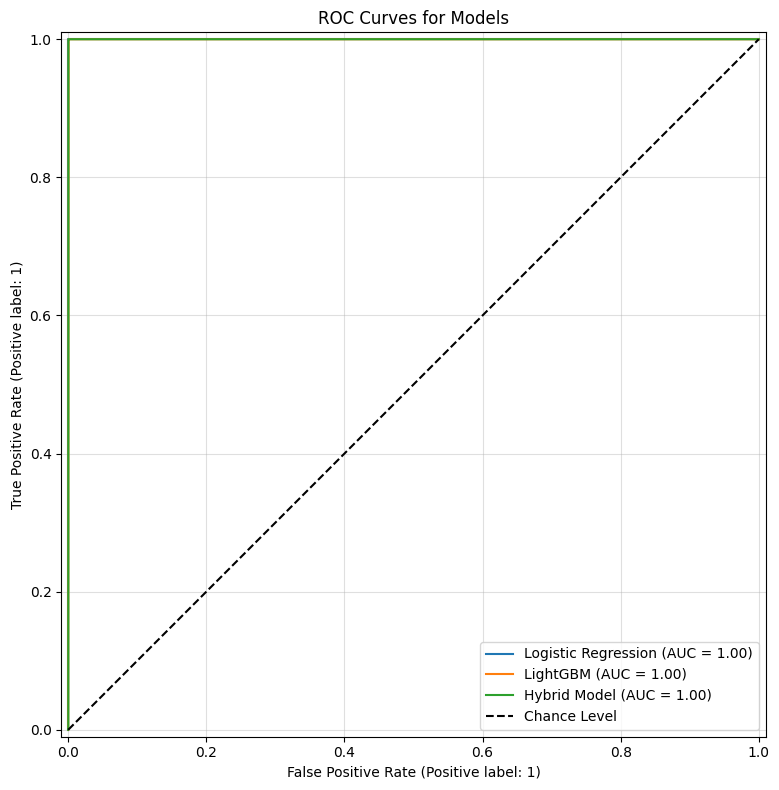

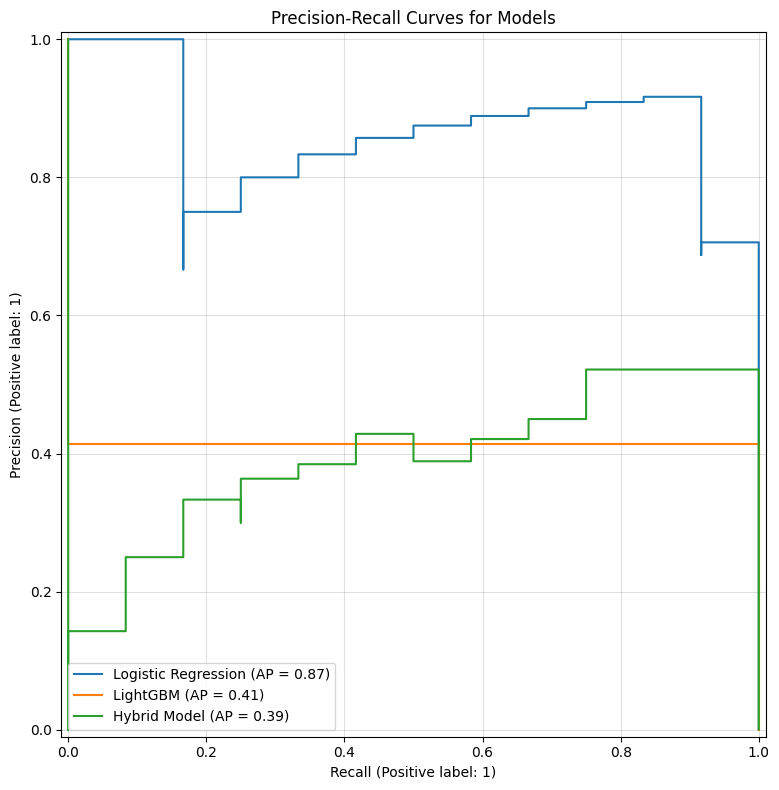

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

def plot_combined_roc_pr_curves(y_true, y_probas_dict, title_prefix="Combined Model Performance"):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Plot ROC Curves
    for model_name, y_proba in y_probas_dict.items():
        RocCurveDisplay.from_predictions(y_true, y_proba, name=model_name, ax=axes[0])
    axes[0].plot([0, 1], [0, 1], 'k--', label='Chance Level')
    axes[0].set_title(f'{title_prefix}: ROC Curves')
    axes[0].legend(loc='lower right')
    axes[0].grid(alpha=0.4)

    # Plot Precision-Recall Curves
    for model_name, y_proba in y_probas_dict.items():
        PrecisionRecallDisplay.from_predictions(y_true, y_proba, name=model_name, ax=axes[1])
    axes[1].set_title(f'{title_prefix}: Precision-Recall Curves')
    axes[1].legend(loc='lower left')
    axes[1].grid(alpha=0.4)

    plt.tight_layout()
    plt.show()
    return fig

# Prepare probabilities for plotting
y_probas_for_plots = {
    'Logistic Regression': y_pred_proba_log_reg,
    'LightGBM': y_pred_proba_lgbm,
    'Hybrid Model': y_pred_proba_hybrid
}

# Plot combined ROC and PR curves
fig_combined_roc_pr = plot_combined_roc_pr_curves(y_test, y_probas_for_plots)
